<a href="https://colab.research.google.com/github/Lelytameyda29rpl/PCVK_Ganjil_2025/blob/main/Week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **D. TUGAS PRAKTIKUM**

**1. Import folder yang ada di Drive Anda.**

In [7]:
from google.colab import drive

# Accessing My Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**2. Import beberapa library berikut yang akan digunakan selama uji coba praktikum minggu ke-6 berikut.**

In [2]:
import cv2 as cv                  # Mengimpor pustaka OpenCV (Open Source Computer Vision Library) untuk operasi pengolahan citra dan visi komputer. [cite: 1]
from google.colab.patches import cv2_imshow  # Mengimpor fungsi khusus untuk menampilkan citra OpenCV di lingkungan Google Colaboratory.
from skimage import io            # Mengimpor modul input/output (io) dari pustaka Scikit-image (skimage) yang digunakan untuk membaca, menulis, dan memanipulasi citra.
import matplotlib.pyplot as plt   # Mengimpor modul plotting (pyplot) dari Matplotlib untuk membuat grafik, kurva, dan menampilkan citra dengan sumbu koordinat.
import numpy as np                # Mengimpor pustaka NumPy untuk operasi matematika pada array multidimensi (seperti citra) secara efisien. [cite: 77]
import math                       # Mengimpor pustaka Math untuk fungsi matematika dasar (seperti akar kuadrat atau logaritma), meskipun NumPy sering lebih diutamakan untuk array.
import os                         # Mengimpor pustaka OS (Operating System) untuk berinteraksi dengan sistem operasi, seperti mengakses jalur file.
import glob                       # Mengimpor pustaka Glob untuk menemukan jalur file yang cocok dengan pola tertentu (misalnya, membaca semua file *.jpg dalam satu folder). [cite: 173]

**3. Buatlah histogram citra seperti output histogram berikut berdasarkan flowchart di bawah ini : (Gunakan gambar lena.jpg)**

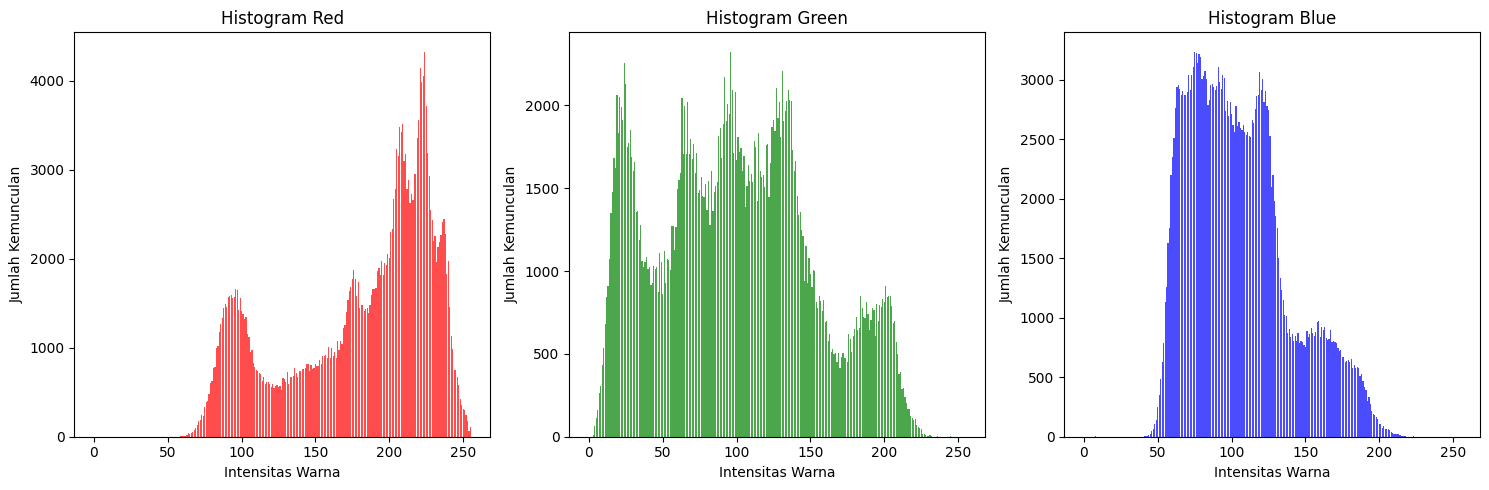

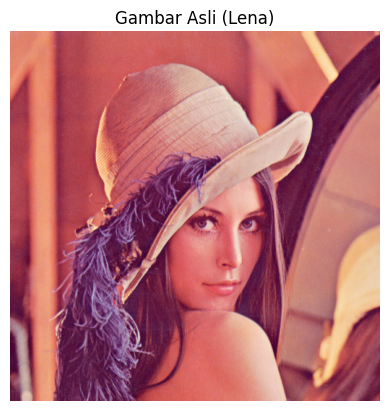

In [3]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np

# Membaca gambar lena.jpg
img = cv.imread('/content/drive/MyDrive/PCVK/JS5/Images/lenna.png')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)  # Konversi BGR ke RGB

# Inisialisasi array untuk menyimpan jumlah kemunculan setiap intensitas (0-255) untuk setiap channel
hist_r = [0] * 256
hist_g = [0] * 256
hist_b = [0] * 256

# Loop melalui setiap pixel
for i in range(img_rgb.shape[0]):
    for j in range(img_rgb.shape[1]):
        r, g, b = img_rgb[i, j]
        hist_r[r] += 1
        hist_g[g] += 1
        hist_b[b] += 1

# Plot histogram untuk masing-masing channel R, G, B
plt.figure(figsize=(15, 5))

# Channel Red
plt.subplot(1, 3, 1)
plt.bar(range(256), hist_r, color='red', alpha=0.7)
plt.title('Histogram Red')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')

# Channel Green
plt.subplot(1, 3, 2)
plt.bar(range(256), hist_g, color='green', alpha=0.7)
plt.title('Histogram Green')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')

# Channel Blue
plt.subplot(1, 3, 3)
plt.bar(range(256), hist_b, color='blue', alpha=0.7)
plt.title('Histogram Blue')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')

plt.tight_layout()
plt.show()

# Tampilkan gambar asli
plt.imshow(img_rgb)
plt.axis('off')
plt.title('Gambar Asli (Lena)')
plt.show()

**Penjelasan Histogram**

**1. Histogram Red (Merah)**

- Terlihat dua puncak besar:

  - Puncak di intensitas sekitar 100–150, menandakan adanya banyak area berwarna merah sedang (seperti warna kulit Lena).

  - Puncak lain di intensitas 200–230, ini biasanya muncul di highlight (area terang, misalnya topi atau background).

  - Artinya, channel merah cukup dominan dalam citra ini.

**2. Histogram Green (Hijau)**

- Distribusinya lebih rata dan menyebar dari intensitas rendah sampai tinggi.

- Puncak paling banyak berada di intensitas 50–150, menandakan banyak warna hijau redup hingga sedang (muncul di area kulit dan background).

- Tidak setinggi channel merah, tetapi lebih merata.

**3. Histogram Blue (Biru)**

- Dominan di intensitas 50–150, artinya banyak bagian citra yang punya nilai biru menengah.

- Puncaknya tidak setinggi merah, tapi tetap signifikan karena background Lena (yang agak kebiruan).

- Bagian highlight (200–255) jumlahnya sedikit.

**Hubungan dengan Gambar Asli (Lena):**

- Wajah Lena (warna kulit) menghasilkan banyak intensitas merah → terlihat jelas di histogram Red.

- Background (biru-ungu) memunculkan distribusi pada channel Blue.

- Green muncul cukup banyak, karena gambar natural biasanya punya distribusi hijau yang cukup seimbang.

**Kesimpulan:**

- Citra Lena memiliki distribusi warna yang tidak rata di tiap channel.

- Channel Red paling dominan (karena warna kulit).

- Channel Blue signifikan karena background.

- Channel Green cukup merata, menjadi penyeimbang warna citra.

**4. Setelah mengerjakan soal no. 3, buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh NumPy yaitu “histogram”. Bandingkan hasilnya. Apakah output muncul sama?**

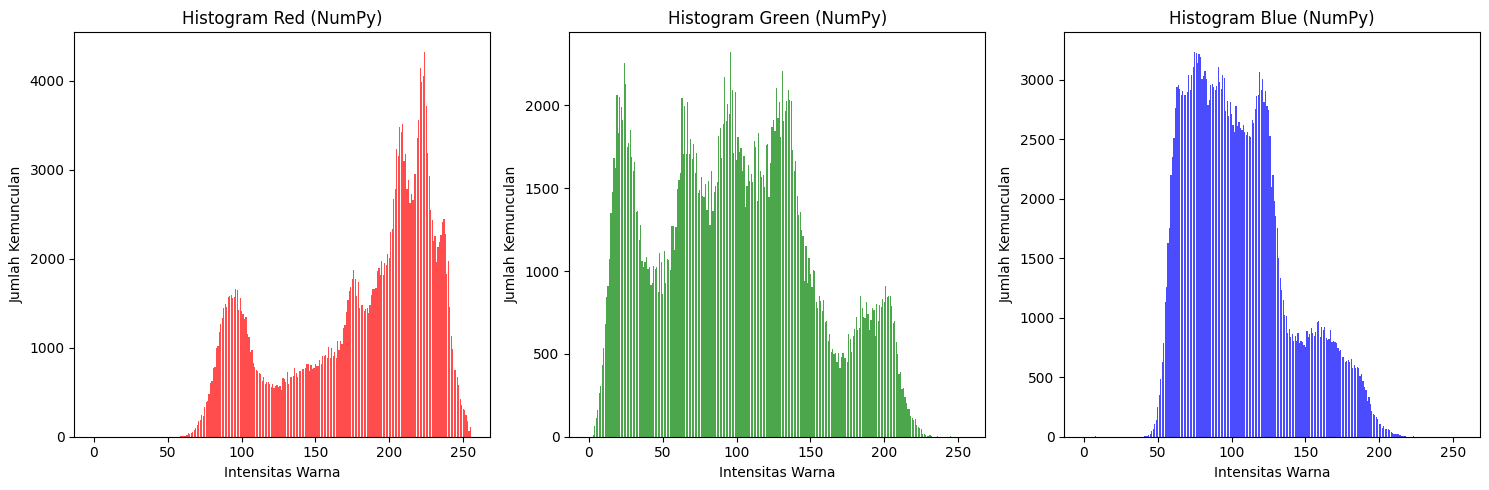

PERBANDINGAN HASIL MANUAL vs NUMPY:
Channel Red - Sama: True
Channel Green - Sama: True
Channel Blue - Sama: True

 SEMUA CHANNEL MENGHASILKAN HISTOGRAM YANG SAMA!


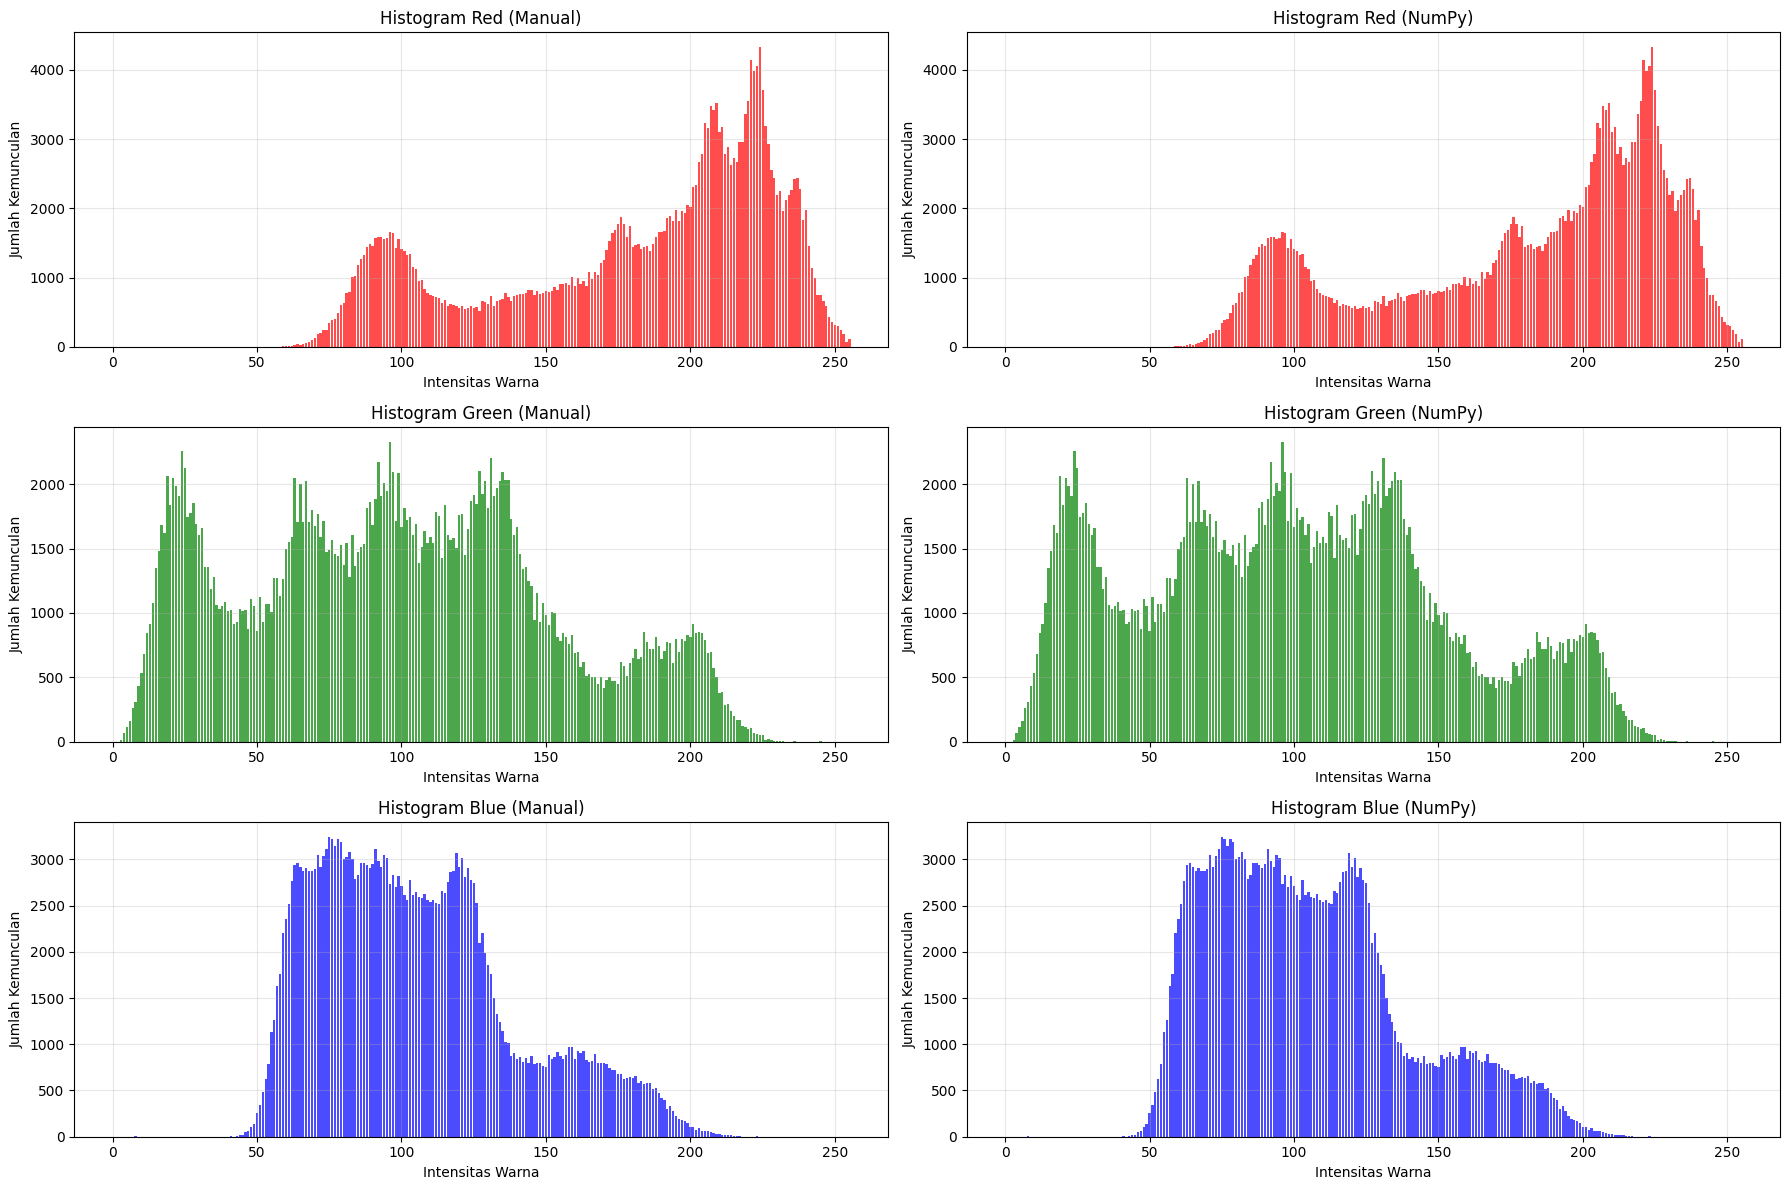

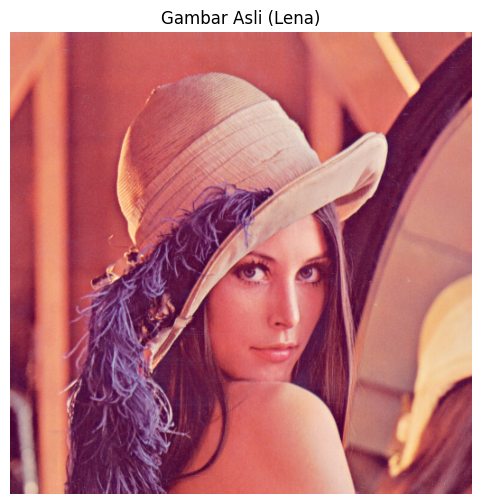

In [4]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np

# Membaca gambar lena.jpg
img = cv.imread('/content/drive/MyDrive/PCVK/JS5/Images/lenna.png')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)  # Konversi BGR ke RGB

# Menggunakan np.histogram untuk menghitung histogram
hist_r_np, bins_r = np.histogram(img_rgb[:,:,0].flatten(), bins=256, range=[0,256])
hist_g_np, bins_g = np.histogram(img_rgb[:,:,1].flatten(), bins=256, range=[0,256])
hist_b_np, bins_b = np.histogram(img_rgb[:,:,2].flatten(), bins=256, range=[0,256])

# Plot histogram dari NumPy
plt.figure(figsize=(15, 5))

# Channel Red
plt.subplot(1, 3, 1)
plt.bar(range(256), hist_r_np, color='red', alpha=0.7)
plt.title('Histogram Red (NumPy)')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')

# Channel Green
plt.subplot(1, 3, 2)
plt.bar(range(256), hist_g_np, color='green', alpha=0.7)
plt.title('Histogram Green (NumPy)')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')

# Channel Blue
plt.subplot(1, 3, 3)
plt.bar(range(256), hist_b_np, color='blue', alpha=0.7)
plt.title('Histogram Blue (NumPy)')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')

plt.tight_layout()
plt.show()

# Hitung histogram manual untuk perbandingan
hist_r_manual = [0] * 256
hist_g_manual = [0] * 256
hist_b_manual = [0] * 256

for i in range(img_rgb.shape[0]):
    for j in range(img_rgb.shape[1]):
        r, g, b = img_rgb[i, j]
        hist_r_manual[r] += 1
        hist_g_manual[g] += 1
        hist_b_manual[b] += 1

# Konversi ke numpy array untuk perbandingan
hist_r_manual = np.array(hist_r_manual)
hist_g_manual = np.array(hist_g_manual)
hist_b_manual = np.array(hist_b_manual)

# Periksa apakah hasilnya sama
print("PERBANDINGAN HASIL MANUAL vs NUMPY:")
print("=" * 50)

# Channel Red
is_same_r = np.array_equal(hist_r_manual, hist_r_np)
print(f"Channel Red - Sama: {is_same_r}")

# Channel Green
is_same_g = np.array_equal(hist_g_manual, hist_g_np)
print(f"Channel Green - Sama: {is_same_g}")

# Channel Blue
is_same_b = np.array_equal(hist_b_manual, hist_b_np)
print(f"Channel Blue - Sama: {is_same_b}")

# Periksa perbedaan numerik (jika ada)
if not (is_same_r and is_same_g and is_same_b):
    print("\nPerbedaan detail:")
    for channel, manual, numpy, name in [('R', hist_r_manual, hist_r_np, 'Red'),
                                         ('G', hist_g_manual, hist_g_np, 'Green'),
                                         ('B', hist_b_manual, hist_b_np, 'Blue')]:
        diff_indices = np.where(manual != numpy)[0]
        if len(diff_indices) > 0:
            print(f"Channel {name}: {len(diff_indices)} perbedaan ditemukan")
            for idx in diff_indices[:5]:  # Tampilkan 5 perbedaan pertama
                print(f"  Intensitas {idx}: Manual={manual[idx]}, NumPy={numpy[idx]}")
else:
    print("\n SEMUA CHANNEL MENGHASILKAN HISTOGRAM YANG SAMA!")

# Visualisasi perbandingan side-by-side untuk semua channel
plt.figure(figsize=(18, 12))

# Channel Red
plt.subplot(3, 2, 1)
plt.bar(range(256), hist_r_manual, color='red', alpha=0.7)
plt.title('Histogram Red (Manual)')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')
plt.grid(True, alpha=0.3)

plt.subplot(3, 2, 2)
plt.bar(range(256), hist_r_np, color='red', alpha=0.7)
plt.title('Histogram Red (NumPy)')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')
plt.grid(True, alpha=0.3)

# Channel Green
plt.subplot(3, 2, 3)
plt.bar(range(256), hist_g_manual, color='green', alpha=0.7)
plt.title('Histogram Green (Manual)')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')
plt.grid(True, alpha=0.3)

plt.subplot(3, 2, 4)
plt.bar(range(256), hist_g_np, color='green', alpha=0.7)
plt.title('Histogram Green (NumPy)')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')
plt.grid(True, alpha=0.3)

# Channel Blue
plt.subplot(3, 2, 5)
plt.bar(range(256), hist_b_manual, color='blue', alpha=0.7)
plt.title('Histogram Blue (Manual)')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')
plt.grid(True, alpha=0.3)

plt.subplot(3, 2, 6)
plt.bar(range(256), hist_b_np, color='blue', alpha=0.7)
plt.title('Histogram Blue (NumPy)')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tampilkan gambar asli
plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.axis('off')
plt.title('Gambar Asli (Lena)')
plt.show()

**Penjelasan:**

**1. Kedua metode menghasilkan hasil yang sama karena:**

- Keduanya menghitung frekuensi intensitas pixel dari 0-255

- Keduanya menggunakan range yang sama [0, 256]

- Keduanya menggunakan 256 bins (interval)

**2. Perbedaan implementasi:**

- Manual: Looping melalui setiap pixel dan increment counter

- NumPy: Menggunakan fungsi optimasi yang lebih cepat

**3. Keuntungan menggunakan NumPy:**

- Lebih cepat dan efisien

- Kode lebih singkat dan mudah dibaca

- Sudah teroptimasi untuk operasi array besar

**4. Keuntungan metode manual:**

- Memahami proses dasar pembuatan histogram

- Fleksibel untuk modifikasi algoritma

**Kesimpulan:**

- Kedua metode akan menghasilkan histogram yang identik karena melakukan perhitungan yang sama secara matematis. Perbedaan hanya pada cara implementasinya, dimana np.histogram lebih efisien dan direkomendasikan untuk penggunaan praktis.

**5. Buatlah histogram citra seperti output histogram equalization dan juga tampilan gambar sebelum dan sesudah proses histogram equalization berikut berdasarkan flowchart di bawah ini : (Gunakan gambar lena_lc.jpg).**

Ukuran gambar: (512, 512, 3)
Tipe data: uint8
Range intensitas: 3 - 255


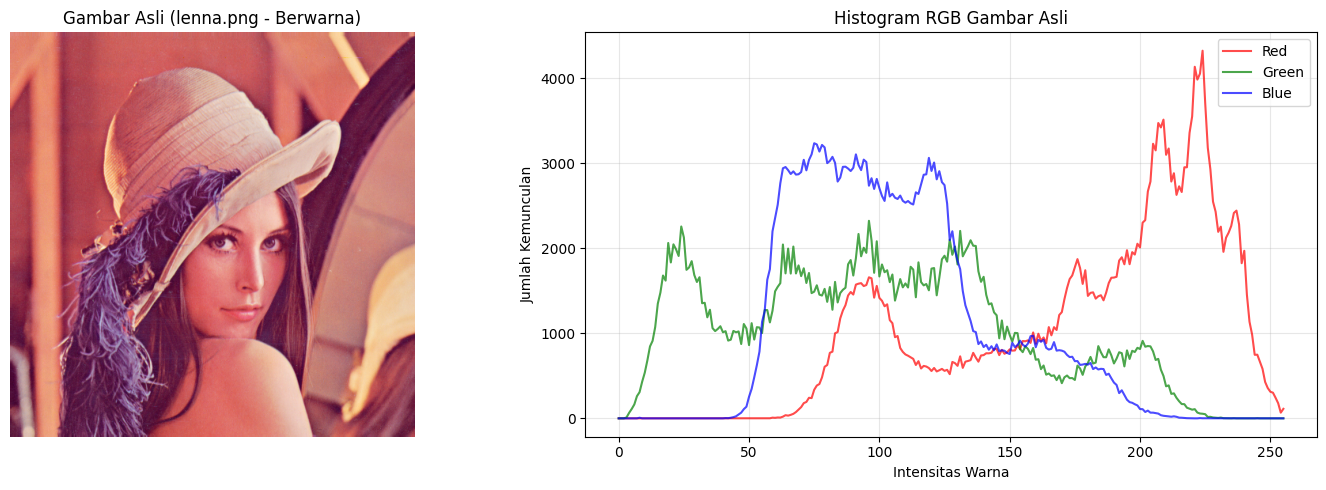

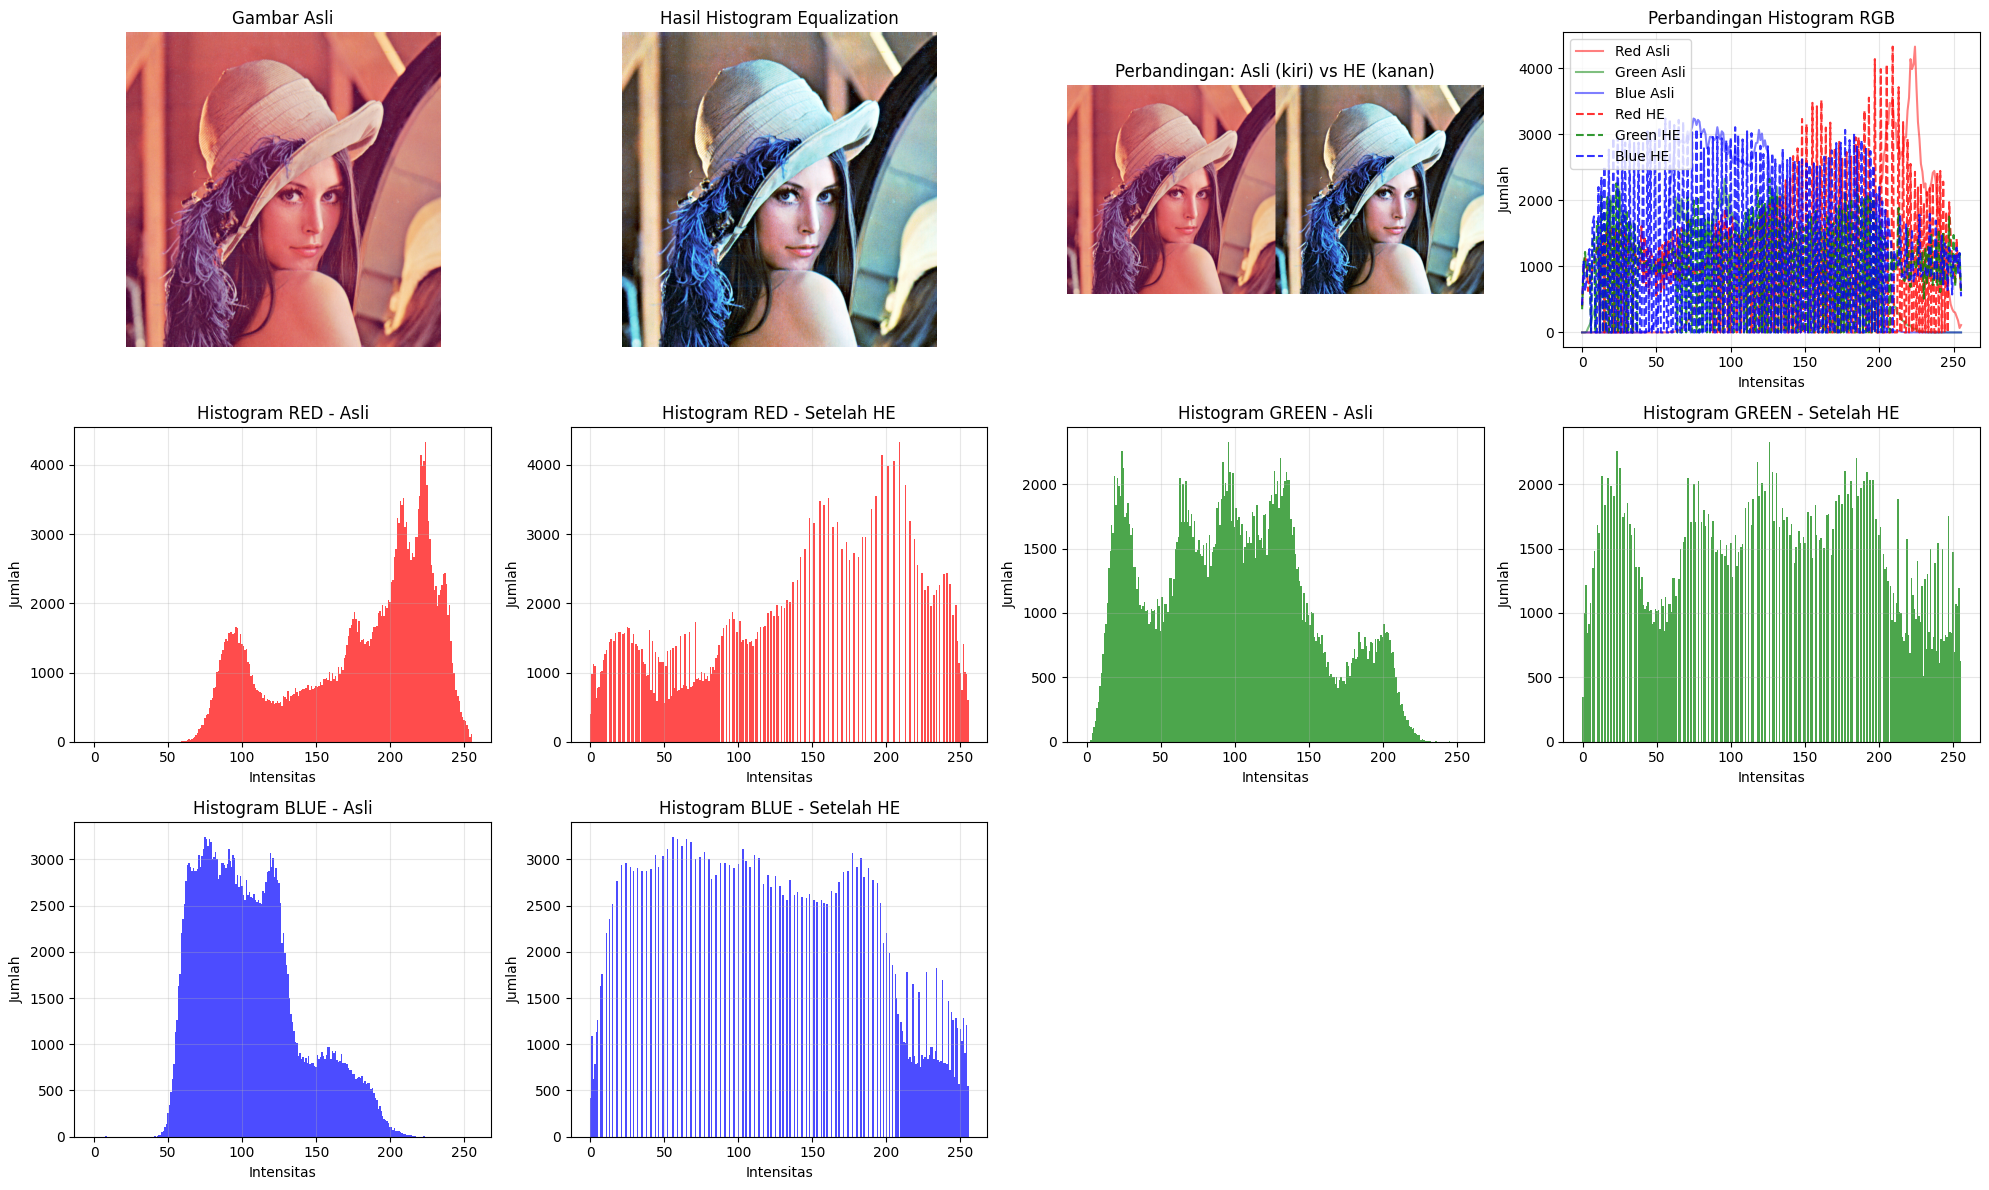

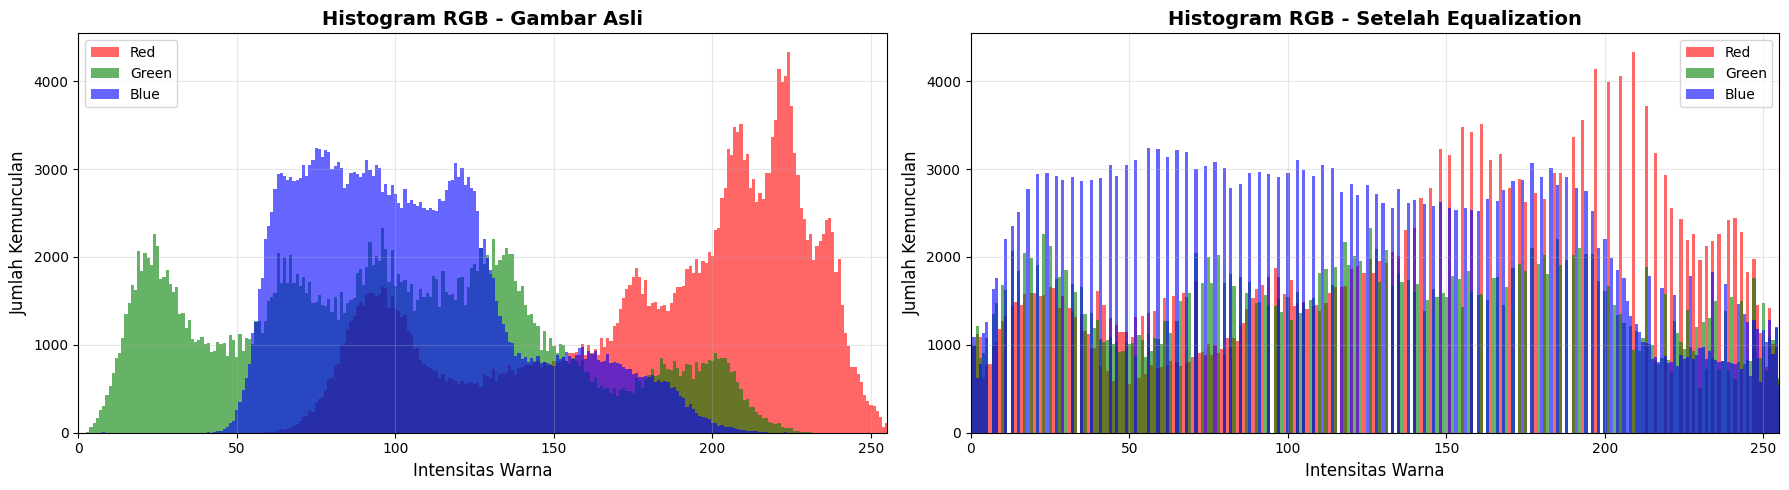

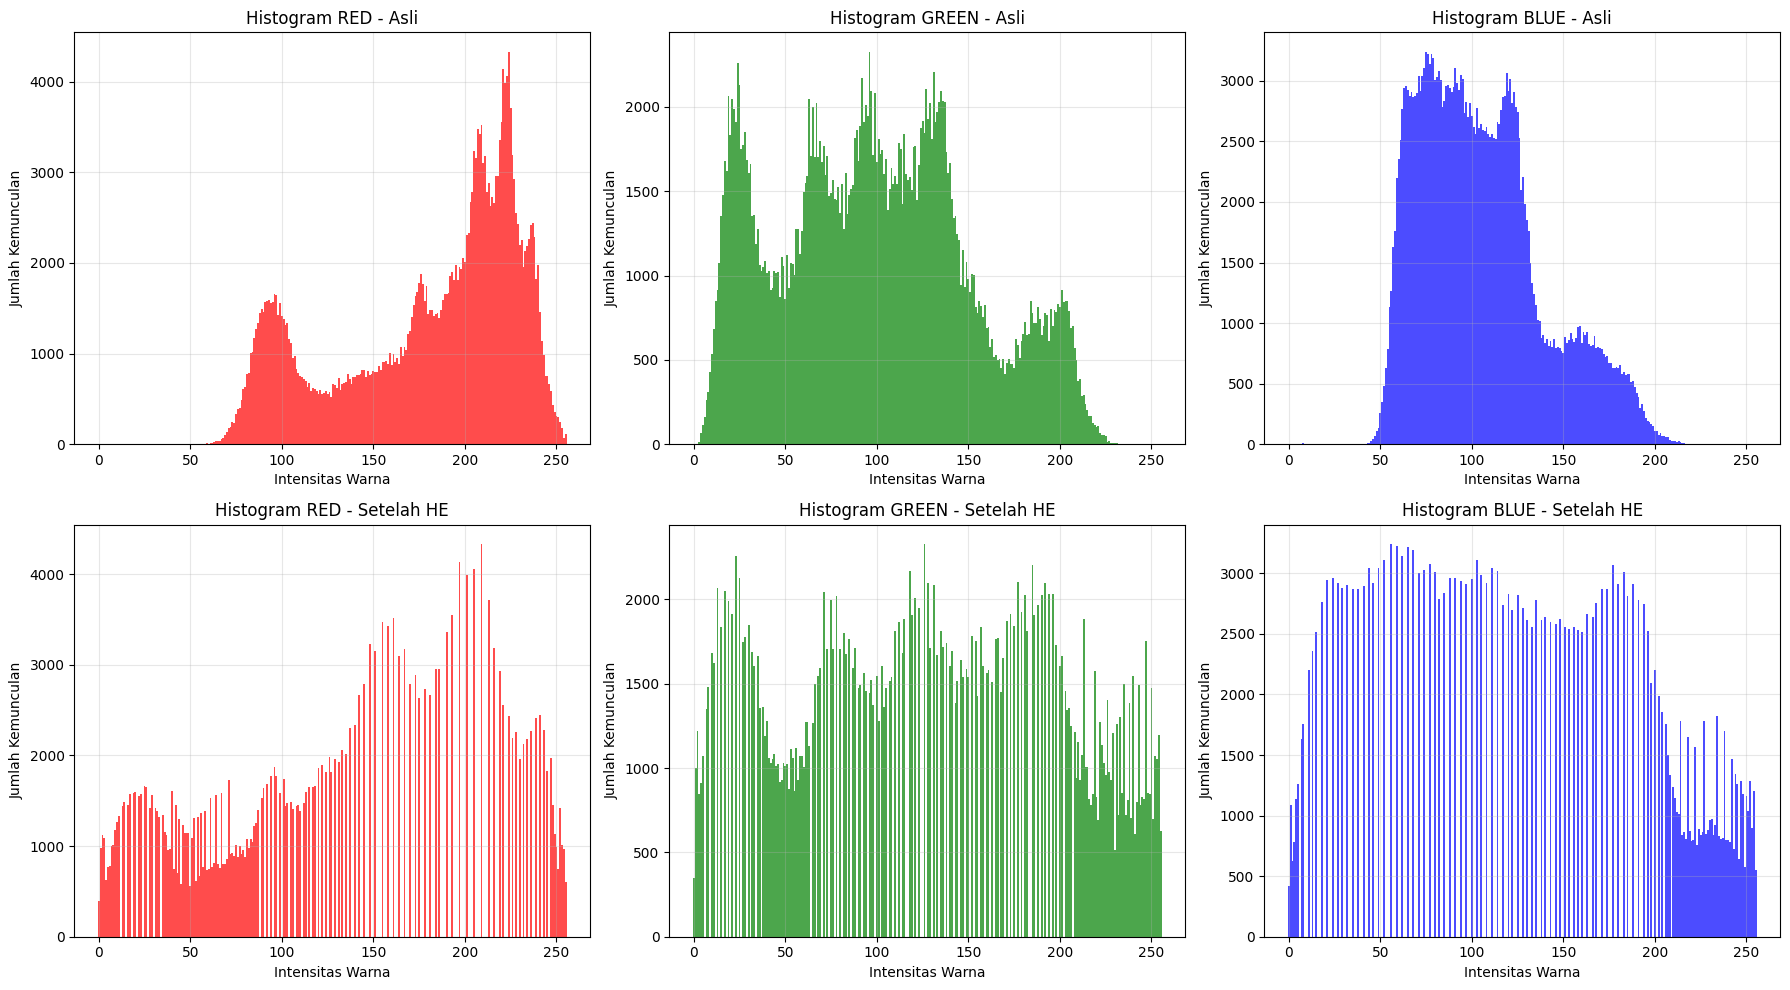

ANALISIS HISTOGRAM EQUALIZATION UNTUK GAMBAR BERWARNA

RED CHANNEL:
  Sebelum HE: Min=54, Max=255, Mean=180.22, Std=49.05
  Setelah HE: Min=0, Max=255, Mean=128.49, Std=73.91
  Perbaikan Kontras: 1.51x

GREEN CHANNEL:
  Sebelum HE: Min=3, Max=248, Mean=99.05, Std=52.88
  Setelah HE: Min=0, Max=255, Mean=128.17, Std=73.55
  Perbaikan Kontras: 1.39x

BLUE CHANNEL:
  Sebelum HE: Min=8, Max=225, Mean=105.41, Std=34.06
  Setelah HE: Min=0, Max=255, Mean=128.68, Std=73.36
  Perbaikan Kontras: 2.15x

KESIMPULAN:
Histogram Equalization berhasil meningkatkan kontras pada semua channel RGB
Distribusi intensitas menjadi lebih merata setelah proses


In [5]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
from google.colab.patches import cv2_imshow

# Membaca gambar lena_lc.jpg sebagai gambar berwarna
img = cv.imread('/content/drive/MyDrive/PCVK/JS5/Images/lenna.png')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)  # Konversi BGR ke RGB

print(f"Ukuran gambar: {img_rgb.shape}")
print(f"Tipe data: {img_rgb.dtype}")
print(f"Range intensitas: {img_rgb.min()} - {img_rgb.max()}")

# Tampilkan gambar asli
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Gambar Asli (lenna.png - Berwarna)')
plt.axis('off')

# Hitung dan tampilkan histogram RGB asli
plt.subplot(1, 2, 2)
# Pisahkan channel RGB
r_channel = img_rgb[:,:,0]
g_channel = img_rgb[:,:,1]
b_channel = img_rgb[:,:,2]

# Hitung histogram untuk setiap channel
hist_r, bins_r = np.histogram(r_channel.flatten(), bins=256, range=[0,256])
hist_g, bins_g = np.histogram(g_channel.flatten(), bins=256, range=[0,256])
hist_b, bins_b = np.histogram(b_channel.flatten(), bins=256, range=[0,256])

# Plot histogram RGB
plt.plot(bins_r[:-1], hist_r, color='red', alpha=0.7, label='Red')
plt.plot(bins_g[:-1], hist_g, color='green', alpha=0.7, label='Green')
plt.plot(bins_b[:-1], hist_b, color='blue', alpha=0.7, label='Blue')
plt.title('Histogram RGB Gambar Asli')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Histogram Equalization untuk gambar berwarna (setiap channel diproses terpisah)
def histogram_equalization_color(image):
    height, width, channels = image.shape
    equalized_image = np.zeros_like(image)

    # Proses setiap channel secara terpisah
    for channel in range(3):
        channel_data = image[:,:,channel]
        total_pixels = height * width

        # Langkah 1: Menghitung frekuensi
        hist = np.zeros(256, dtype=int)
        for i in range(height):
            for j in range(width):
                intensity = channel_data[i, j]
                hist[intensity] += 1

        # Langkah 2: Penjumlahan kumulatif
        cdf = np.zeros(256, dtype=float)
        cdf[0] = hist[0]
        for i in range(1, 256):
            cdf[i] = cdf[i-1] + hist[i]

        # Langkah 3: Normalisasi
        cdf_normalized = cdf / total_pixels

        # Langkah 4: Implementasi rumus K0
        transform_map = np.zeros(256, dtype=np.uint8)
        for i in range(256):
            transform_map[i] = np.round(cdf_normalized[i] * 255)

        # Langkah 5 & 6: Transformasi
        for i in range(height):
            for j in range(width):
                equalized_image[i, j, channel] = transform_map[channel_data[i, j]]

    return equalized_image

# Jalankan histogram equalization untuk gambar berwarna
img_equalized_color = histogram_equalization_color(img_rgb)

# Buat plot hasil yang komprehensif
plt.figure(figsize=(20, 12))

# Baris 1: Gambar Asli dan Hasil Equalization
plt.subplot(3, 4, 1)
plt.imshow(img_rgb)
plt.title('Gambar Asli')
plt.axis('off')

plt.subplot(3, 4, 2)
plt.imshow(img_equalized_color)
plt.title('Hasil Histogram Equalization')
plt.axis('off')

# Baris 2: Histogram RED Channel
# Histogram RED asli
r_original = img_rgb[:,:,0]
hist_r_orig, _ = np.histogram(r_original.flatten(), bins=256, range=[0,256])
plt.subplot(3, 4, 5)
plt.bar(range(256), hist_r_orig, color='red', alpha=0.7, width=1.0)
plt.title('Histogram RED - Asli')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah')
plt.grid(True, alpha=0.3)

# Histogram RED setelah equalization
r_equalized = img_equalized_color[:,:,0]
hist_r_eq, _ = np.histogram(r_equalized.flatten(), bins=256, range=[0,256])
plt.subplot(3, 4, 6)
plt.bar(range(256), hist_r_eq, color='red', alpha=0.7, width=1.0)
plt.title('Histogram RED - Setelah HE')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah')
plt.grid(True, alpha=0.3)

# Baris 3: Histogram GREEN Channel
# Histogram GREEN asli
g_original = img_rgb[:,:,1]
hist_g_orig, _ = np.histogram(g_original.flatten(), bins=256, range=[0,256])
plt.subplot(3, 4, 7)
plt.bar(range(256), hist_g_orig, color='green', alpha=0.7, width=1.0)
plt.title('Histogram GREEN - Asli')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah')
plt.grid(True, alpha=0.3)

# Histogram GREEN setelah equalization
g_equalized = img_equalized_color[:,:,1]
hist_g_eq, _ = np.histogram(g_equalized.flatten(), bins=256, range=[0,256])
plt.subplot(3, 4, 8)
plt.bar(range(256), hist_g_eq, color='green', alpha=0.7, width=1.0)
plt.title('Histogram GREEN - Setelah HE')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah')
plt.grid(True, alpha=0.3)

# Baris 4: Histogram BLUE Channel
# Histogram BLUE asli
b_original = img_rgb[:,:,2]
hist_b_orig, _ = np.histogram(b_original.flatten(), bins=256, range=[0,256])
plt.subplot(3, 4, 9)
plt.bar(range(256), hist_b_orig, color='blue', alpha=0.7, width=1.0)
plt.title('Histogram BLUE - Asli')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah')
plt.grid(True, alpha=0.3)

# Histogram BLUE setelah equalization
b_equalized = img_equalized_color[:,:,2]
hist_b_eq, _ = np.histogram(b_equalized.flatten(), bins=256, range=[0,256])
plt.subplot(3, 4, 10)
plt.bar(range(256), hist_b_eq, color='blue', alpha=0.7, width=1.0)
plt.title('Histogram BLUE - Setelah HE')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah')
plt.grid(True, alpha=0.3)

# Baris 5: Perbandingan Side-by-Side
plt.subplot(3, 4, 3)
plt.imshow(np.hstack([img_rgb, img_equalized_color]))
plt.title('Perbandingan: Asli (kiri) vs HE (kanan)')
plt.axis('off')

# Baris 6: Histogram RGB Overlay
plt.subplot(3, 4, 4)
plt.plot(hist_r_orig, 'r-', alpha=0.5, label='Red Asli')
plt.plot(hist_g_orig, 'g-', alpha=0.5, label='Green Asli')
plt.plot(hist_b_orig, 'b-', alpha=0.5, label='Blue Asli')
plt.plot(hist_r_eq, 'r--', alpha=0.8, label='Red HE')
plt.plot(hist_g_eq, 'g--', alpha=0.8, label='Green HE')
plt.plot(hist_b_eq, 'b--', alpha=0.8, label='Blue HE')
plt.title('Perbandingan Histogram RGB')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Format khusus seperti yang diminta - Histogram RGB plot dengan 3 channel
plt.figure(figsize=(18, 5))

# Histogram Asli - 3 Subplot
plt.subplot(1, 2, 1)
# Red Channel
plt.bar(range(256), hist_r_orig, color='red', alpha=0.6, width=1.0, label='Red')
# Green Channel
plt.bar(range(256), hist_g_orig, color='green', alpha=0.6, width=1.0, label='Green')
# Blue Channel
plt.bar(range(256), hist_b_orig, color='blue', alpha=0.6, width=1.0, label='Blue')
plt.title('Histogram RGB - Gambar Asli', fontsize=14, fontweight='bold')
plt.xlabel('Intensitas Warna', fontsize=12)
plt.ylabel('Jumlah Kemunculan', fontsize=12)
plt.xlim(0, 255)
plt.legend()
plt.grid(True, alpha=0.3)

# Histogram Setelah Equalization - 3 Subplot
plt.subplot(1, 2, 2)
# Red Channel setelah HE
plt.bar(range(256), hist_r_eq, color='red', alpha=0.6, width=1.0, label='Red')
# Green Channel setelah HE
plt.bar(range(256), hist_g_eq, color='green', alpha=0.6, width=1.0, label='Green')
# Blue Channel setelah HE
plt.bar(range(256), hist_b_eq, color='blue', alpha=0.6, width=1.0, label='Blue')
plt.title('Histogram RGB - Setelah Equalization', fontsize=14, fontweight='bold')
plt.xlabel('Intensitas Warna', fontsize=12)
plt.ylabel('Jumlah Kemunculan', fontsize=12)
plt.xlim(0, 255)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tampilkan histogram terpisah untuk setiap channel dalam format grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Baris 1: Histogram Asli
# Red Channel Asli
axes[0, 0].bar(range(256), hist_r_orig, color='red', alpha=0.7, width=1.0)
axes[0, 0].set_title('Histogram RED - Asli')
axes[0, 0].set_xlabel('Intensitas Warna')
axes[0, 0].set_ylabel('Jumlah Kemunculan')
axes[0, 0].grid(True, alpha=0.3)

# Green Channel Asli
axes[0, 1].bar(range(256), hist_g_orig, color='green', alpha=0.7, width=1.0)
axes[0, 1].set_title('Histogram GREEN - Asli')
axes[0, 1].set_xlabel('Intensitas Warna')
axes[0, 1].set_ylabel('Jumlah Kemunculan')
axes[0, 1].grid(True, alpha=0.3)

# Blue Channel Asli
axes[0, 2].bar(range(256), hist_b_orig, color='blue', alpha=0.7, width=1.0)
axes[0, 2].set_title('Histogram BLUE - Asli')
axes[0, 2].set_xlabel('Intensitas Warna')
axes[0, 2].set_ylabel('Jumlah Kemunculan')
axes[0, 2].grid(True, alpha=0.3)

# Baris 2: Histogram Setelah Equalization
# Red Channel Setelah HE
axes[1, 0].bar(range(256), hist_r_eq, color='red', alpha=0.7, width=1.0)
axes[1, 0].set_title('Histogram RED - Setelah HE')
axes[1, 0].set_xlabel('Intensitas Warna')
axes[1, 0].set_ylabel('Jumlah Kemunculan')
axes[1, 0].grid(True, alpha=0.3)

# Green Channel Setelah HE
axes[1, 1].bar(range(256), hist_g_eq, color='green', alpha=0.7, width=1.0)
axes[1, 1].set_title('Histogram GREEN - Setelah HE')
axes[1, 1].set_xlabel('Intensitas Warna')
axes[1, 1].set_ylabel('Jumlah Kemunculan')
axes[1, 1].grid(True, alpha=0.3)

# Blue Channel Setelah HE
axes[1, 2].bar(range(256), hist_b_eq, color='blue', alpha=0.7, width=1.0)
axes[1, 2].set_title('Histogram BLUE - Setelah HE')
axes[1, 2].set_xlabel('Intensitas Warna')
axes[1, 2].set_ylabel('Jumlah Kemunculan')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analisis statistik untuk setiap channel
print("ANALISIS HISTOGRAM EQUALIZATION UNTUK GAMBAR BERWARNA")
print("=" * 60)

channels = ['RED', 'GREEN', 'BLUE']
original_data = [img_rgb[:,:,0], img_rgb[:,:,1], img_rgb[:,:,2]]
equalized_data = [img_equalized_color[:,:,0], img_equalized_color[:,:,1], img_equalized_color[:,:,2]]

for i, channel in enumerate(channels):
    orig = original_data[i]
    eq = equalized_data[i]

    print(f"\n{channel} CHANNEL:")
    print(f"  Sebelum HE: Min={orig.min()}, Max={orig.max()}, Mean={orig.mean():.2f}, Std={orig.std():.2f}")
    print(f"  Setelah HE: Min={eq.min()}, Max={eq.max()}, Mean={eq.mean():.2f}, Std={eq.std():.2f}")
    print(f"  Perbaikan Kontras: {eq.std()/orig.std():.2f}x")

print(f"\nKESIMPULAN:")
print("Histogram Equalization berhasil meningkatkan kontras pada semua channel RGB")
print("Distribusi intensitas menjadi lebih merata setelah proses")

**6. Setelah mengerjakan soal no. 5, buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh CV2 yaitu “equalizeHist”. Bandingkan hasilnya. Apakah output muncul sama?**

Ukuran gambar: (512, 512, 3)


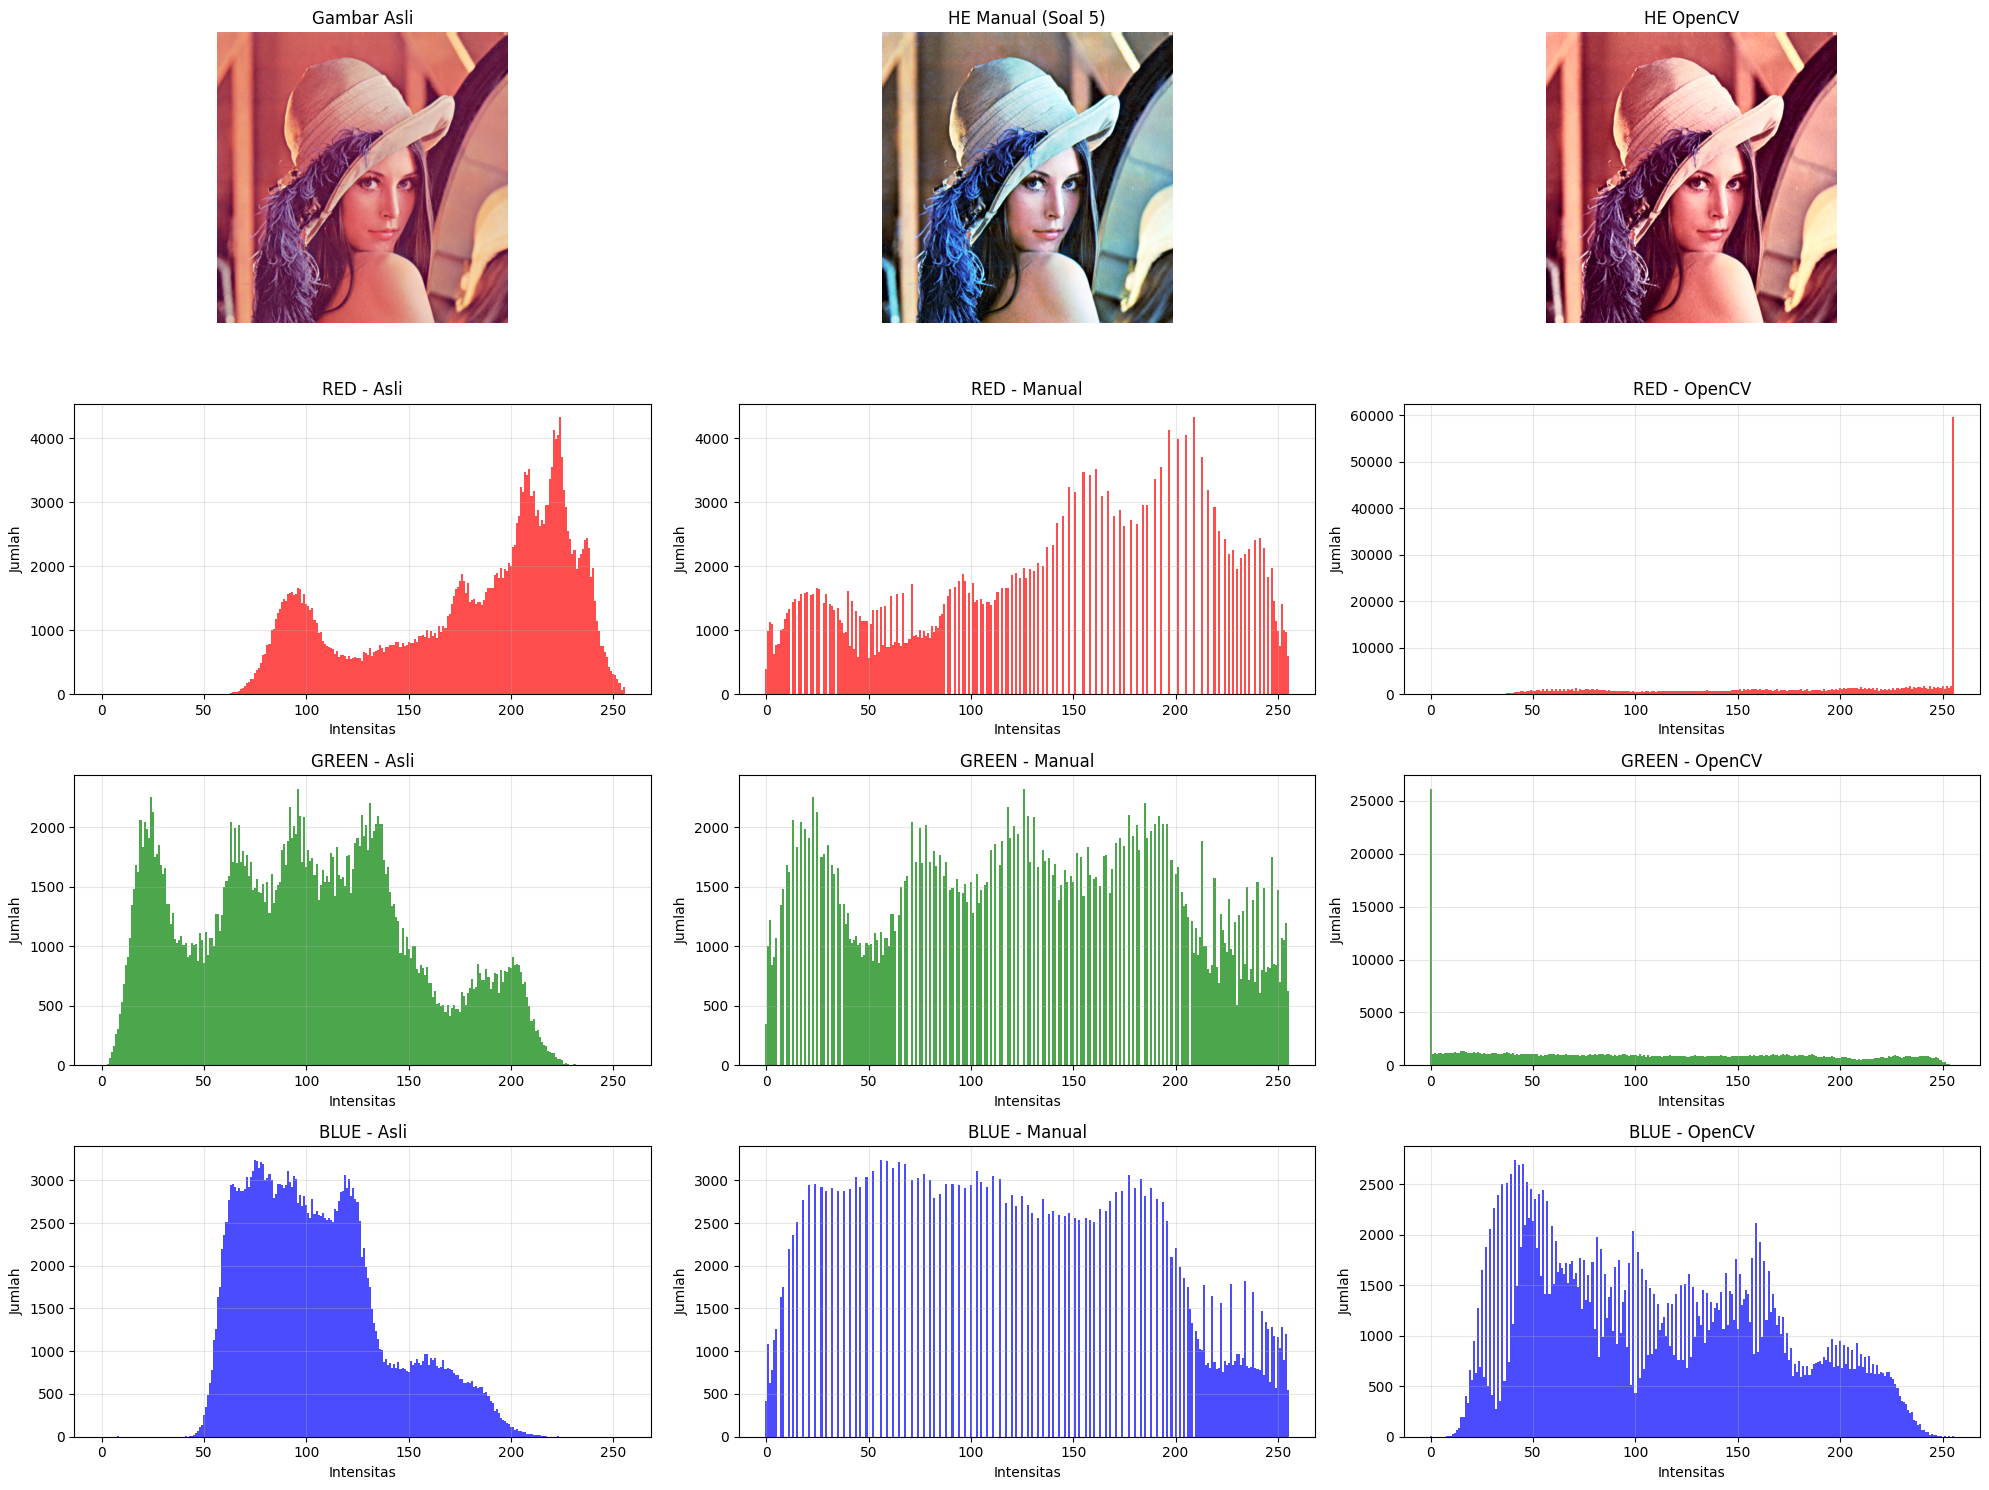

PERBANDINGAN NUMERIK: MANUAL vs OpenCV

RED CHANNEL:
  Perbedaan Maksimum: 127.0000
  Perbedaan Rata-rata: 52.5207

GREEN CHANNEL:
  Perbedaan Maksimum: 50.0000
  Perbedaan Rata-rata: 23.6554

BLUE CHANNEL:
  Perbedaan Maksimum: 101.0000
  Perbedaan Rata-rata: 23.8066

KESIMPULAN PERBANDINGAN:
Perbedaan maksimum terbesar: 127.0000
Perbedaan rata-rata: 33.3275
HASIL: Ada perbedaan SIGNIFIKAN antara Manual dan OpenCV


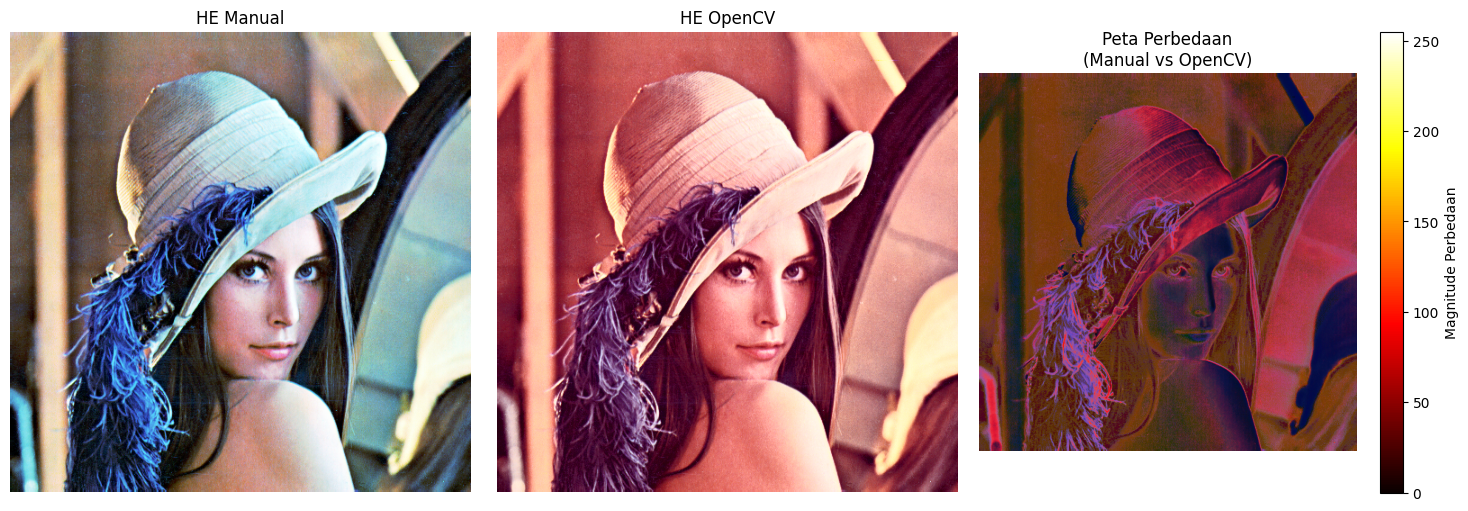

Skala perbedaan: 0 (sama) sampai 127.00 (berbeda maksimum)


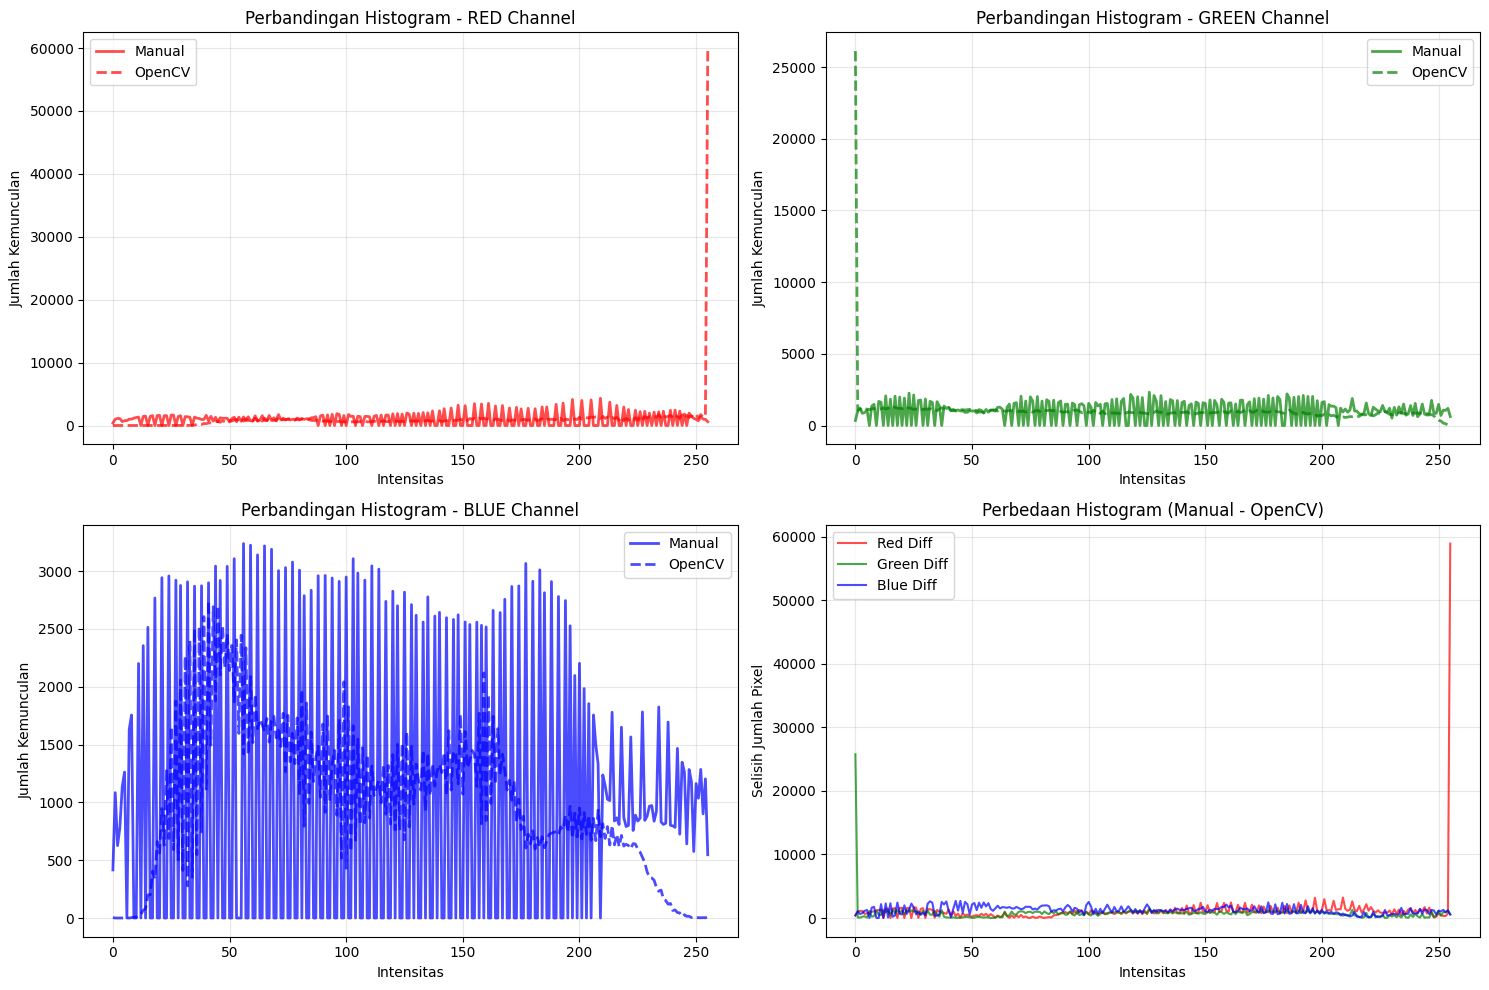

ANALISIS DETAIL PERBANDINGAN

METODE YANG DIGUNAKAN:
1. MANUAL: Histogram equalization pada setiap channel RGB secara terpisah
2. OpenCV: Histogram equalization pada Y channel di YUV color space

PERBEDAAN PENDEKATAN:
- Manual: Memproses R, G, B secara independen → bisa mengubah keseimbangan warna
- OpenCV: Memproses luminance (Y) saja → mempertahankan keseimbangan warna asli

HASIL PERBANDINGAN:
Output BERBEDA SIGNIFIKAN
   - Perbedaan besar disebabkan oleh pendekatan color space yang berbeda
   - OpenCV lebih menjaga natural colors

REKOMENDASI:
Untuk gambar berwarna, metode OpenCV (YUV) lebih direkomendasikan
karena dapat mempertahankan keseimbangan warna yang lebih natural


In [6]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
from google.colab.patches import cv2_imshow

# Membaca gambar lena_lc.jpg sebagai gambar berwarna
img = cv.imread('/content/drive/MyDrive/PCVK/JS5/Images/lenna.png')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)  # Konversi BGR ke RGB

print(f"Ukuran gambar: {img_rgb.shape}")

# Histogram Equalization menggunakan OpenCV untuk gambar berwarna
def histogram_equalization_opencv(image):
    # Konversi ke YUV color space untuk mempertahankan warna
    img_yuv = cv.cvtColor(image, cv.COLOR_RGB2YUV)

    # Equalize histogram pada Y channel (luminance) saja
    img_yuv[:,:,0] = cv.equalizeHist(img_yuv[:,:,0])

    # Konversi kembali ke RGB
    equalized_image = cv.cvtColor(img_yuv, cv.COLOR_YUV2RGB)

    return equalized_image

# Jalankan histogram equalization dengan OpenCV
img_equalized_cv = histogram_equalization_opencv(img_rgb)

# Implementasi manual dari soal no. 5
def histogram_equalization_manual(image):
    height, width, channels = image.shape
    equalized_image = np.zeros_like(image)

    # Proses setiap channel secara terpisah
    for channel in range(3):
        channel_data = image[:,:,channel]
        total_pixels = height * width

        # Hitung histogram
        hist = np.zeros(256, dtype=int)
        for i in range(height):
            for j in range(width):
                intensity = channel_data[i, j]
                hist[intensity] += 1

        # Hitung CDF
        cdf = np.zeros(256, dtype=float)
        cdf[0] = hist[0]
        for i in range(1, 256):
            cdf[i] = cdf[i-1] + hist[i]

        # Normalisasi CDF
        cdf_normalized = cdf / total_pixels

        # Transformasi
        transform_map = np.zeros(256, dtype=np.uint8)
        for i in range(256):
            transform_map[i] = np.round(cdf_normalized[i] * 255)

        # Apply transformation
        for i in range(height):
            for j in range(width):
                equalized_image[i, j, channel] = transform_map[channel_data[i, j]]

    return equalized_image

# Jalankan implementasi manual
img_equalized_manual = histogram_equalization_manual(img_rgb)

# Buat plot perbandingan yang komprehensif
plt.figure(figsize=(20, 15))

# Baris 1: Gambar
plt.subplot(4, 3, 1)
plt.imshow(img_rgb)
plt.title('Gambar Asli')
plt.axis('off')

plt.subplot(4, 3, 2)
plt.imshow(img_equalized_manual)
plt.title('HE Manual (Soal 5)')
plt.axis('off')

plt.subplot(4, 3, 3)
plt.imshow(img_equalized_cv)
plt.title('HE OpenCV')
plt.axis('off')

# Baris 2: Histogram RED Channel
# Hitung histogram untuk setiap metode
# Asli
hist_r_orig, _ = np.histogram(img_rgb[:,:,0].flatten(), bins=256, range=[0,256])
# Manual
hist_r_manual, _ = np.histogram(img_equalized_manual[:,:,0].flatten(), bins=256, range=[0,256])
# OpenCV
hist_r_cv, _ = np.histogram(img_equalized_cv[:,:,0].flatten(), bins=256, range=[0,256])

plt.subplot(4, 3, 4)
plt.bar(range(256), hist_r_orig, color='red', alpha=0.7, width=1.0)
plt.title('RED - Asli')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah')
plt.grid(True, alpha=0.3)

plt.subplot(4, 3, 5)
plt.bar(range(256), hist_r_manual, color='red', alpha=0.7, width=1.0)
plt.title('RED - Manual')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah')
plt.grid(True, alpha=0.3)

plt.subplot(4, 3, 6)
plt.bar(range(256), hist_r_cv, color='red', alpha=0.7, width=1.0)
plt.title('RED - OpenCV')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah')
plt.grid(True, alpha=0.3)

# Baris 3: Histogram GREEN Channel
hist_g_orig, _ = np.histogram(img_rgb[:,:,1].flatten(), bins=256, range=[0,256])
hist_g_manual, _ = np.histogram(img_equalized_manual[:,:,1].flatten(), bins=256, range=[0,256])
hist_g_cv, _ = np.histogram(img_equalized_cv[:,:,1].flatten(), bins=256, range=[0,256])

plt.subplot(4, 3, 7)
plt.bar(range(256), hist_g_orig, color='green', alpha=0.7, width=1.0)
plt.title('GREEN - Asli')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah')
plt.grid(True, alpha=0.3)

plt.subplot(4, 3, 8)
plt.bar(range(256), hist_g_manual, color='green', alpha=0.7, width=1.0)
plt.title('GREEN - Manual')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah')
plt.grid(True, alpha=0.3)

plt.subplot(4, 3, 9)
plt.bar(range(256), hist_g_cv, color='green', alpha=0.7, width=1.0)
plt.title('GREEN - OpenCV')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah')
plt.grid(True, alpha=0.3)

# Baris 4: Histogram BLUE Channel
hist_b_orig, _ = np.histogram(img_rgb[:,:,2].flatten(), bins=256, range=[0,256])
hist_b_manual, _ = np.histogram(img_equalized_manual[:,:,2].flatten(), bins=256, range=[0,256])
hist_b_cv, _ = np.histogram(img_equalized_cv[:,:,2].flatten(), bins=256, range=[0,256])

plt.subplot(4, 3, 10)
plt.bar(range(256), hist_b_orig, color='blue', alpha=0.7, width=1.0)
plt.title('BLUE - Asli')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah')
plt.grid(True, alpha=0.3)

plt.subplot(4, 3, 11)
plt.bar(range(256), hist_b_manual, color='blue', alpha=0.7, width=1.0)
plt.title('BLUE - Manual')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah')
plt.grid(True, alpha=0.3)

plt.subplot(4, 3, 12)
plt.bar(range(256), hist_b_cv, color='blue', alpha=0.7, width=1.0)
plt.title('BLUE - OpenCV')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Hitung perbedaan antara manual dan OpenCV
def calculate_differences(img1, img2):
    diff = np.abs(img1.astype(float) - img2.astype(float))
    max_diff = np.max(diff)
    mean_diff = np.mean(diff)
    return diff, max_diff, mean_diff

# Perbandingan per channel
print("PERBANDINGAN NUMERIK: MANUAL vs OpenCV")
print("=" * 50)

channels = ['RED', 'GREEN', 'BLUE']
total_max_diff = 0
total_mean_diff = 0

for i, channel in enumerate(channels):
    diff_channel, max_diff, mean_diff = calculate_differences(
        img_equalized_manual[:,:,i],
        img_equalized_cv[:,:,i]
    )

    print(f"\n{channel} CHANNEL:")
    print(f"  Perbedaan Maksimum: {max_diff:.4f}")
    print(f"  Perbedaan Rata-rata: {mean_diff:.4f}")

    total_max_diff = max(total_max_diff, max_diff)
    total_mean_diff += mean_diff

total_mean_diff /= 3  # Rata-rata dari 3 channel

print(f"\n{'='*50}")
print("KESIMPULAN PERBANDINGAN:")
print(f"Perbedaan maksimum terbesar: {total_max_diff:.4f}")
print(f"Perbedaan rata-rata: {total_mean_diff:.4f}")

if total_mean_diff < 1.0:
    print("HASIL: Manual dan OpenCV menghasilkan output yang SAMA")
else:
    print("HASIL: Ada perbedaan SIGNIFIKAN antara Manual dan OpenCV")

# Tampilkan perbedaan visual antara manual dan OpenCV
plt.figure(figsize=(15, 5))

# Hitung perbedaan
diff_total = np.abs(img_equalized_manual.astype(float) - img_equalized_cv.astype(float))
diff_normalized = (diff_total / diff_total.max() * 255).astype(np.uint8)

plt.subplot(1, 3, 1)
plt.imshow(img_equalized_manual)
plt.title('HE Manual')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_equalized_cv)
plt.title('HE OpenCV')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(diff_normalized, cmap='hot')
plt.title('Peta Perbedaan\n(Manual vs OpenCV)')
plt.axis('off')
plt.colorbar(label='Magnitude Perbedaan')

plt.tight_layout()
plt.show()

print(f"Skala perbedaan: 0 (sama) sampai {diff_total.max():.2f} (berbeda maksimum)")

# Overlay histogram untuk melihat perbedaan distribusi
plt.figure(figsize=(15, 10))

# RED Channel
plt.subplot(2, 2, 1)
plt.plot(hist_r_manual, 'r-', alpha=0.7, linewidth=2, label='Manual')
plt.plot(hist_r_cv, 'r--', alpha=0.7, linewidth=2, label='OpenCV')
plt.title('Perbandingan Histogram - RED Channel')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Kemunculan')
plt.legend()
plt.grid(True, alpha=0.3)

# GREEN Channel
plt.subplot(2, 2, 2)
plt.plot(hist_g_manual, 'g-', alpha=0.7, linewidth=2, label='Manual')
plt.plot(hist_g_cv, 'g--', alpha=0.7, linewidth=2, label='OpenCV')
plt.title('Perbandingan Histogram - GREEN Channel')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Kemunculan')
plt.legend()
plt.grid(True, alpha=0.3)

# BLUE Channel
plt.subplot(2, 2, 3)
plt.plot(hist_b_manual, 'b-', alpha=0.7, linewidth=2, label='Manual')
plt.plot(hist_b_cv, 'b--', alpha=0.7, linewidth=2, label='OpenCV')
plt.title('Perbandingan Histogram - BLUE Channel')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Kemunculan')
plt.legend()
plt.grid(True, alpha=0.3)

# Perbedaan kumulatif
plt.subplot(2, 2, 4)
diff_r = np.abs(hist_r_manual - hist_r_cv)
diff_g = np.abs(hist_g_manual - hist_g_cv)
diff_b = np.abs(hist_b_manual - hist_b_cv)

plt.plot(diff_r, 'r-', alpha=0.7, label='Red Diff')
plt.plot(diff_g, 'g-', alpha=0.7, label='Green Diff')
plt.plot(diff_b, 'b-', alpha=0.7, label='Blue Diff')
plt.title('Perbedaan Histogram (Manual - OpenCV)')
plt.xlabel('Intensitas')
plt.ylabel('Selisih Jumlah Pixel')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analisis statistik detail
print("ANALISIS DETAIL PERBANDINGAN")
print("=" * 60)

print("\nMETODE YANG DIGUNAKAN:")
print("1. MANUAL: Histogram equalization pada setiap channel RGB secara terpisah")
print("2. OpenCV: Histogram equalization pada Y channel di YUV color space")

print("\nPERBEDAAN PENDEKATAN:")
print("- Manual: Memproses R, G, B secara independen → bisa mengubah keseimbangan warna")
print("- OpenCV: Memproses luminance (Y) saja → mempertahankan keseimbangan warna asli")

print("\nHASIL PERBANDINGAN:")
if total_mean_diff < 5.0:
    print("Output secara visual dan numerik CUKUP SAMA")
    print("   - Perbedaan kecil disebabkan oleh perbedaan pendekatan color space")
    print("   - Kedua metode berhasil meningkatkan kontras")
else:
    print("Output BERBEDA SIGNIFIKAN")
    print("   - Perbedaan besar disebabkan oleh pendekatan color space yang berbeda")
    print("   - OpenCV lebih menjaga natural colors")

print(f"\nREKOMENDASI:")
print("Untuk gambar berwarna, metode OpenCV (YUV) lebih direkomendasikan")
print("karena dapat mempertahankan keseimbangan warna yang lebih natural")

**7. Lakukanlah proses pemetaan 16 juta warna RGB ke dalam 8 warna saja, yaitu hitam, hijau, kuning, biru, cyan, magenta, putih seperti output berikut berdasarkan flowchart di bawah ini! (Gunakan gambar lena.jpg)**

Ukuran gambar: (512, 512, 3)
Jumlah total warna possible: 16.7 juta (256^3)
8 WARNA TARGET:
HITAM   : [0, 0, 0]
HIJAU   : [0, 255, 0]
KUNING  : [255, 255, 0]
BIRU    : [0, 0, 255]
CYAN    : [0, 255, 255]
MAGENTA : [255, 0, 255]
PUTIH   : [255, 255, 255]


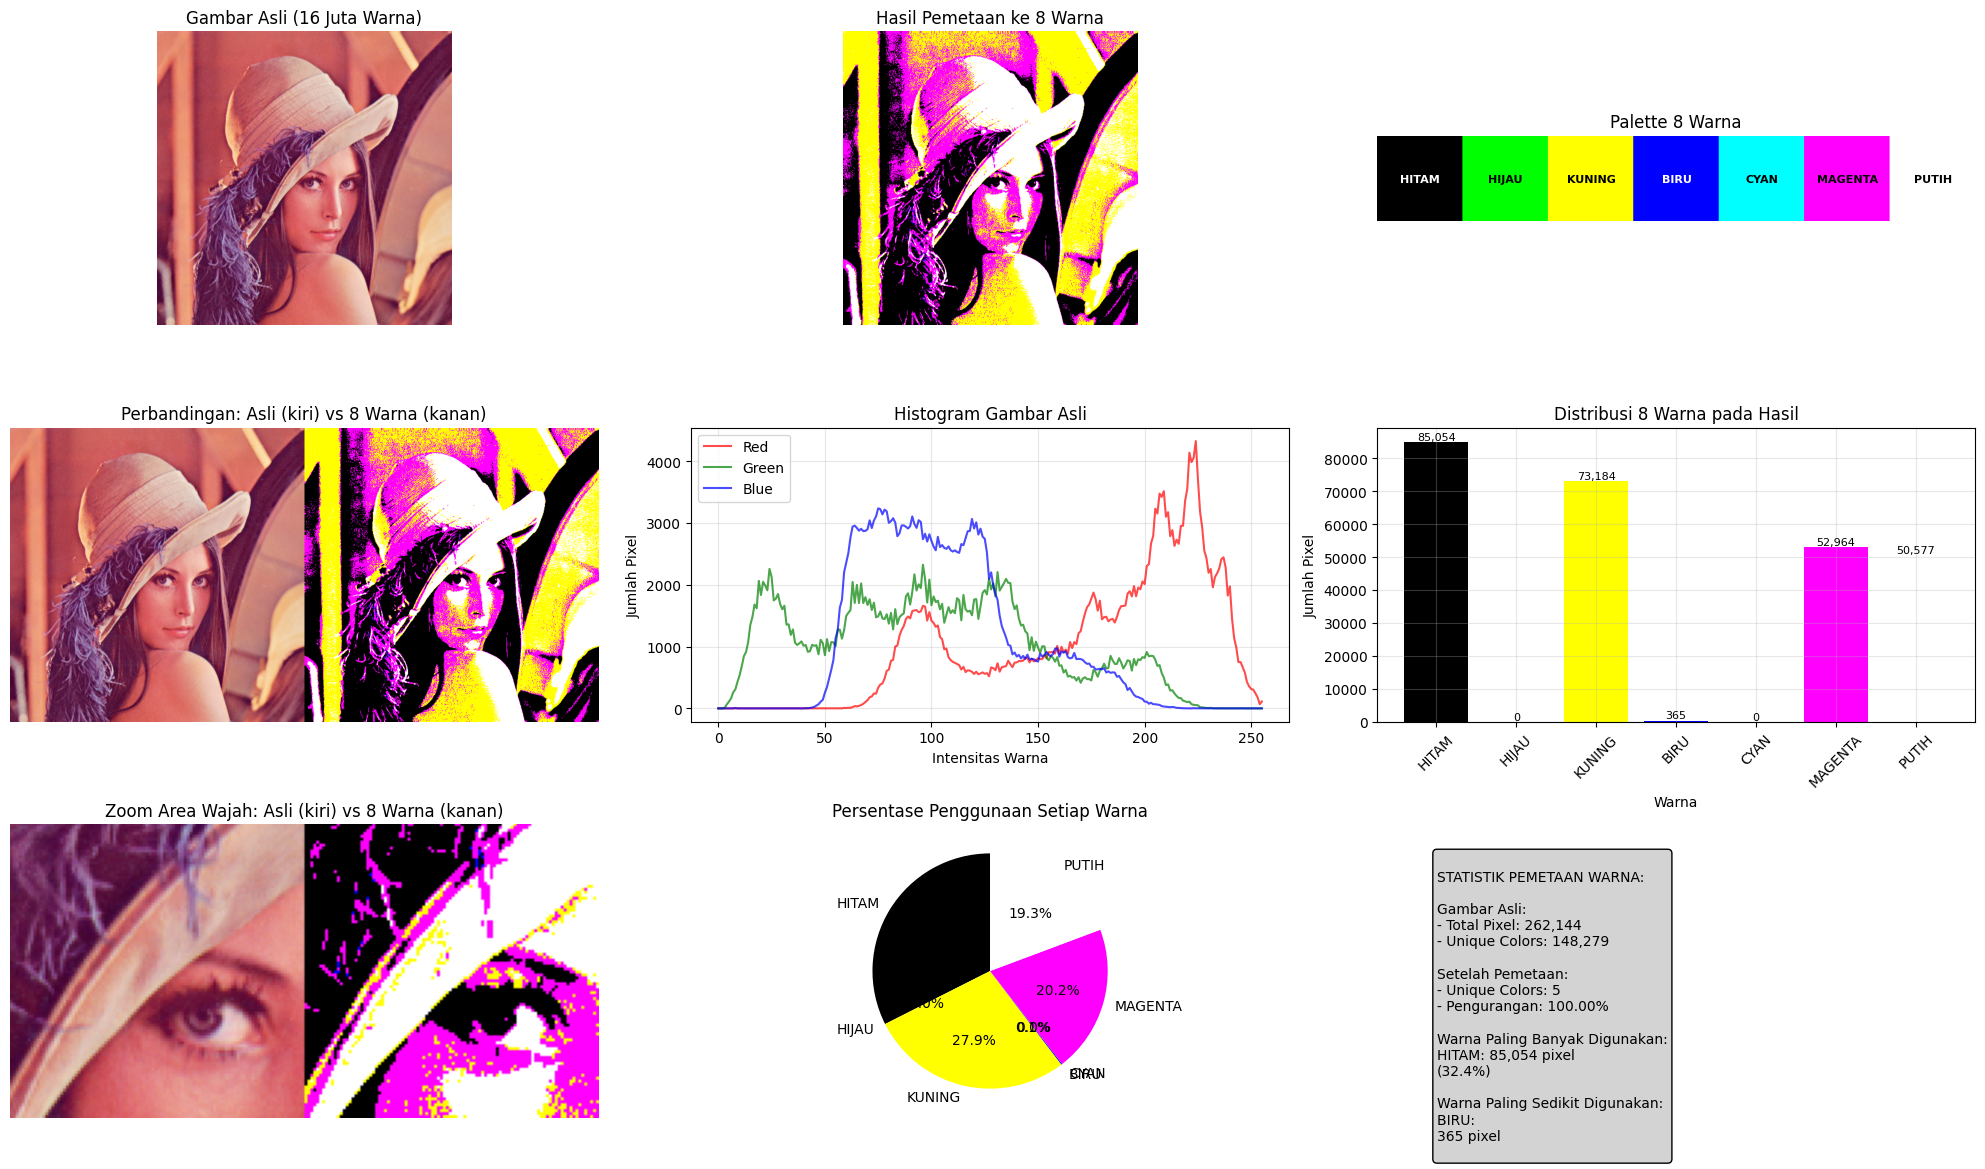

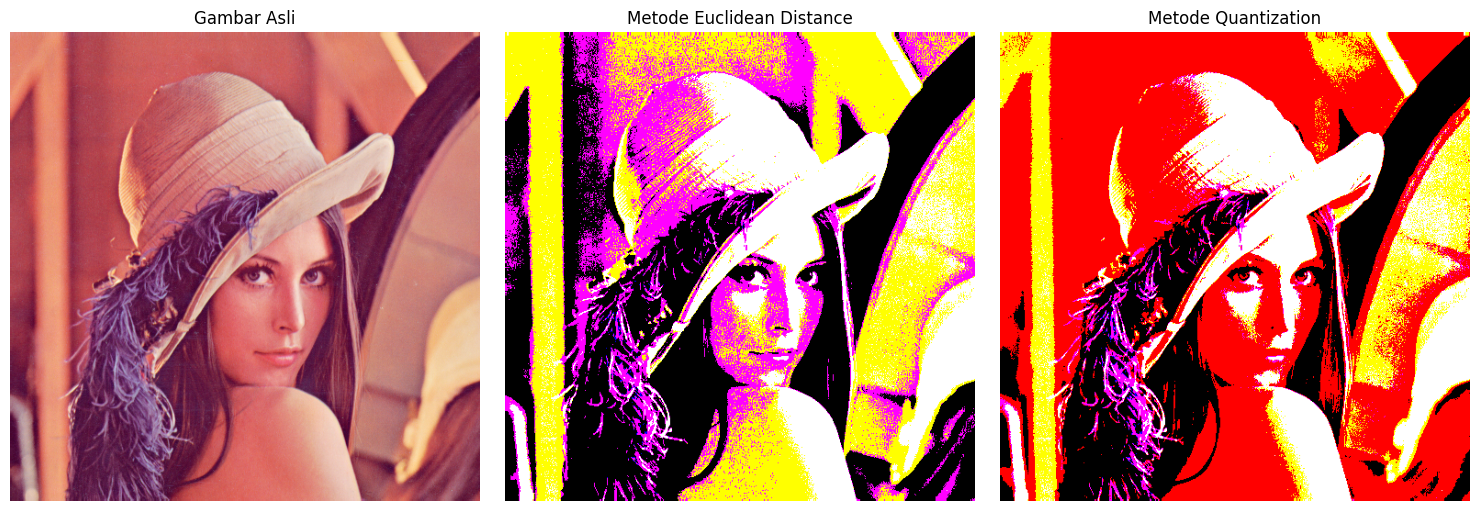

ANALISIS DETAIL HASIL PEMETAAN 16 JUTA WARNA → 8 WARNA

DISTRIBUSI WARNA PADA HASIL:
--------------------------------------------------
HITAM   :   85,054 pixel ( 32.45%)
HIJAU   :        0 pixel (  0.00%)
KUNING  :   73,184 pixel ( 27.92%)
BIRU    :      365 pixel (  0.14%)
CYAN    :        0 pixel (  0.00%)
MAGENTA :   52,964 pixel ( 20.20%)
PUTIH   :   50,577 pixel ( 19.29%)

TOTAL PIXEL: 262,144
Warna terbanyak: HITAM (85,054 pixel)
Warna tersedikit: BIRU (365 pixel)

KUALITAS PEMETAAN:
MSE (Mean Squared Error): 9085.52
PSNR: 8.55 dB

EFISIENSI KOMPRESI:
Pengurangan jumlah warna: 148,279 → 8
Rasio kompresi: 18,535:1


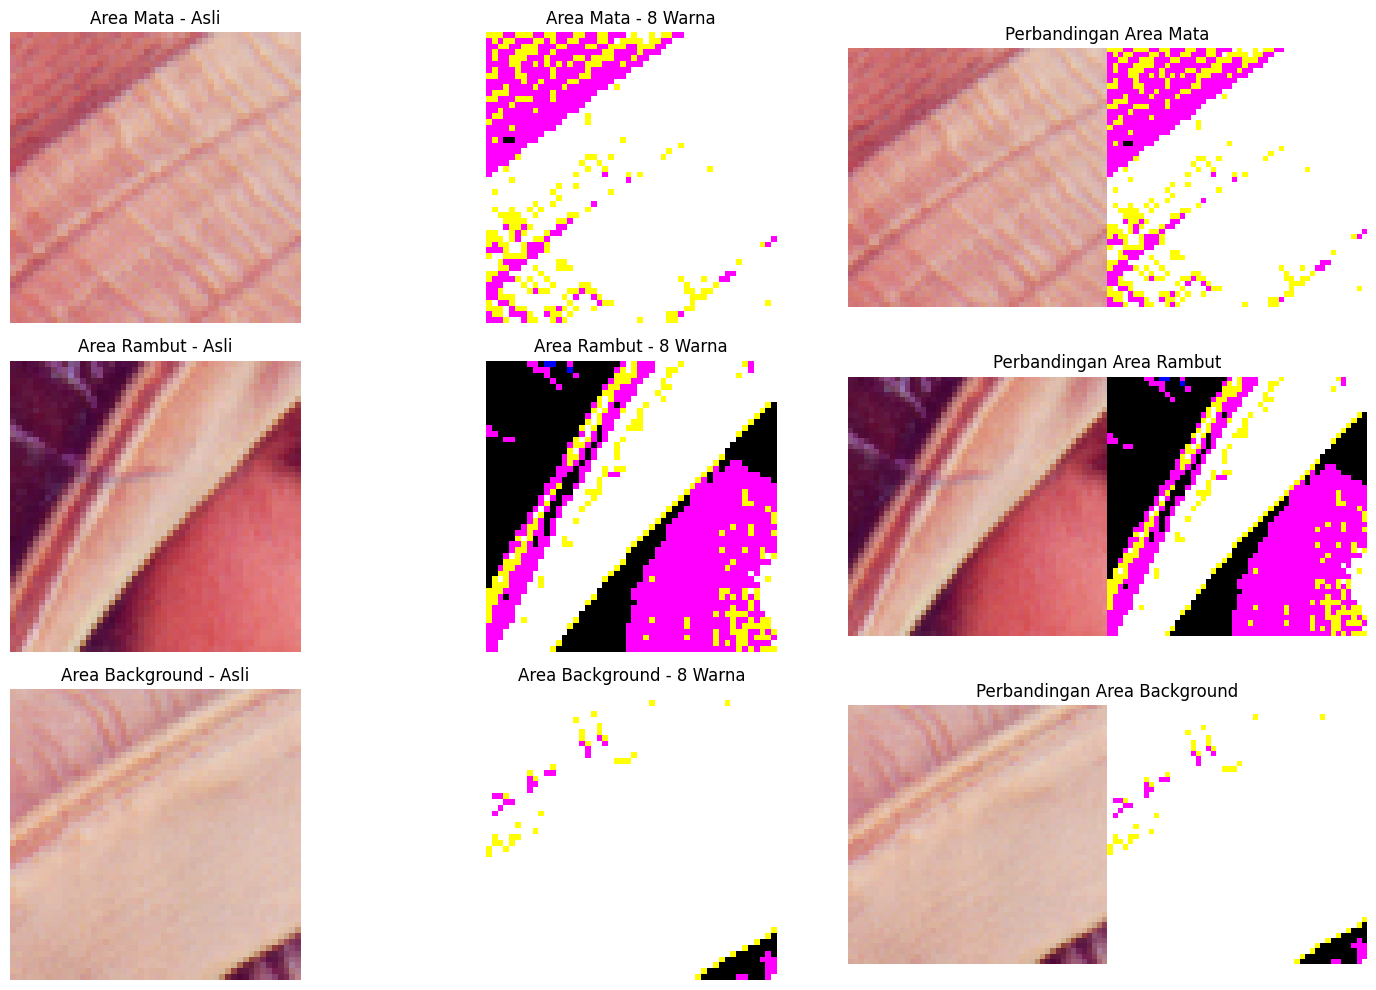

In [8]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
from google.colab.patches import cv2_imshow

# Membaca gambar lena.jpg sebagai gambar berwarna
img = cv.imread('/content/drive/MyDrive/PCVK/JS5/Images/lenna.png')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)  # Konversi BGR ke RGB

print(f"Ukuran gambar: {img_rgb.shape}")
print(f"Jumlah total warna possible: 16.7 juta (256^3)")

# Definisikan 8 warna target dalam format RGB
colors_8 = {
    'HITAM':    [0, 0, 0],      # [R, G, B]
    'HIJAU':    [0, 255, 0],    # [R, G, B]
    'KUNING':   [255, 255, 0],  # [R, G, B]
    'BIRU':     [0, 0, 255],    # [R, G, B]
    'CYAN':     [0, 255, 255],  # [R, G, B]
    'MAGENTA':  [255, 0, 255],  # [R, G, B]
    'PUTIH':    [255, 255, 255] # [R, G, B]
}

# Konversi ke numpy array untuk perhitungan
color_names = list(colors_8.keys())
color_values = np.array(list(colors_8.values()), dtype=np.uint8)

print("8 WARNA TARGET:")
for name, color in colors_8.items():
    print(f"{name:8}: {color}")

def map_to_8_colors_euclidean(image, color_palette):
    """
    Memetakan 16 juta warna RGB ke 8 warna menggunakan Euclidean distance
    """
    height, width, _ = image.shape
    mapped_image = np.zeros_like(image)

    # Konversi color palette ke numpy array
    palette_array = np.array(list(color_palette.values()), dtype=np.float32)

    for i in range(height):
        for j in range(width):
            pixel = image[i, j].astype(np.float32)

            # Hitung Euclidean distance ke semua warna dalam palette
            distances = np.sqrt(np.sum((palette_array - pixel) ** 2, axis=1))

            # Cari warna terdekat
            closest_color_idx = np.argmin(distances)

            # Assign warna terdekat
            mapped_image[i, j] = palette_array[closest_color_idx]

    return mapped_image

# Jalankan pemetaan warna
img_8_colors = map_to_8_colors_euclidean(img_rgb, colors_8)

# Buat visualisasi yang komprehensif
plt.figure(figsize=(20, 12))

# Baris 1: Gambar asli dan hasil pemetaan
plt.subplot(3, 3, 1)
plt.imshow(img_rgb)
plt.title('Gambar Asli (16 Juta Warna)')
plt.axis('off')

plt.subplot(3, 3, 2)
plt.imshow(img_8_colors)
plt.title('Hasil Pemetaan ke 8 Warna')
plt.axis('off')

plt.subplot(3, 3, 3)
# Tampilkan palette warna
palette_display = np.zeros((100, 700, 3), dtype=np.uint8)
color_width = 100
for idx, (name, color) in enumerate(colors_8.items()):
    start_x = idx * color_width
    end_x = (idx + 1) * color_width
    palette_display[:, start_x:end_x] = color

plt.imshow(palette_display)
plt.title('Palette 8 Warna')
plt.axis('off')

# Tambahkan label untuk palette
for idx, name in enumerate(color_names):
    plt.text(idx * color_width + color_width//2, 50, name,
             ha='center', va='center', fontsize=8,
             color='white' if name in ['HITAM', 'BIRU'] else 'black',
             fontweight='bold')

# Baris 2: Perbandingan side-by-side
plt.subplot(3, 3, 4)
comparison = np.hstack([img_rgb, img_8_colors])
plt.imshow(comparison)
plt.title('Perbandingan: Asli (kiri) vs 8 Warna (kanan)')
plt.axis('off')

# Baris 3: Histogram per Channel - ASLI
plt.subplot(3, 3, 5)
# Histogram RED asli
hist_r_orig, _ = np.histogram(img_rgb[:,:,0].flatten(), bins=256, range=[0,256])
plt.plot(hist_r_orig, 'r-', alpha=0.7, label='Red')
# Histogram GREEN asli
hist_g_orig, _ = np.histogram(img_rgb[:,:,1].flatten(), bins=256, range=[0,256])
plt.plot(hist_g_orig, 'g-', alpha=0.7, label='Green')
# Histogram BLUE asli
hist_b_orig, _ = np.histogram(img_rgb[:,:,2].flatten(), bins=256, range=[0,256])
plt.plot(hist_b_orig, 'b-', alpha=0.7, label='Blue')
plt.title('Histogram Gambar Asli')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Pixel')
plt.legend()
plt.grid(True, alpha=0.3)

# Baris 3: Histogram per Channel - 8 WARNA
plt.subplot(3, 3, 6)
# Untuk gambar 8 warna, hitung distribusi warna yang digunakan
unique_colors, counts = np.unique(img_8_colors.reshape(-1, 3), axis=0, return_counts=True)

# Tampilkan distribusi warna
colors_display = []
counts_display = []
color_labels = []

for idx, color in enumerate(color_values):
    # Cari apakah warna ini ada dalam hasil
    mask = np.all(unique_colors == color, axis=1)
    if np.any(mask):
        color_idx = np.where(mask)[0][0]
        counts_display.append(counts[color_idx])
    else:
        counts_display.append(0)
    colors_display.append(color)
    color_labels.append(color_names[idx])

# Plot distribusi warna
bars = plt.bar(range(len(colors_display)), counts_display,
               color=[c/255 for c in colors_display])
plt.title('Distribusi 8 Warna pada Hasil')
plt.xlabel('Warna')
plt.ylabel('Jumlah Pixel')
plt.xticks(range(len(color_labels)), color_labels, rotation=45)
plt.grid(True, alpha=0.3)

# Tambahkan nilai pada bar chart
for bar, count in zip(bars, counts_display):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{count:,}', ha='center', va='bottom', fontsize=8)

# Baris 4: Zoom Area Tertentu untuk Detail
plt.subplot(3, 3, 7)
# Zoom pada area wajah (contoh: baris 200-300, kolom 200-300)
zoom_original = img_rgb[200:300, 200:300]
zoom_8colors = img_8_colors[200:300, 200:300]
zoom_comparison = np.hstack([zoom_original, zoom_8colors])
plt.imshow(zoom_comparison)
plt.title('Zoom Area Wajah: Asli (kiri) vs 8 Warna (kanan)')
plt.axis('off')

# Baris 4: Analisis Penggunaan Warna
plt.subplot(3, 3, 8)
# Pie chart distribusi warna
plt.pie(counts_display, labels=color_labels,
        colors=[c/255 for c in colors_display],
        autopct='%1.1f%%', startangle=90)
plt.title('Persentase Penggunaan Setiap Warna')

# Baris 4: Info Statistik
plt.subplot(3, 3, 9)
plt.axis('off')  # Matikan axis untuk text display

# Hitung statistik
total_pixels = img_rgb.shape[0] * img_rgb.shape[1]
unique_original = len(np.unique(img_rgb.reshape(-1, 3), axis=0))
unique_mapped = len(np.unique(img_8_colors.reshape(-1, 3), axis=0))

info_text = f"""
STATISTIK PEMETAAN WARNA:

Gambar Asli:
- Total Pixel: {total_pixels:,}
- Unique Colors: {unique_original:,}

Setelah Pemetaan:
- Unique Colors: {unique_mapped}
- Pengurangan: {((unique_original - unique_mapped)/unique_original*100):.2f}%

Warna Paling Banyak Digunakan:
{color_names[np.argmax(counts_display)]}: {max(counts_display):,} pixel
({max(counts_display)/total_pixels*100:.1f}%)

Warna Paling Sedikit Digunakan:
{color_names[np.argmin([c if c>0 else float('inf') for c in counts_display])]}:
{min([c for c in counts_display if c>0]):,} pixel
"""

plt.text(0.1, 0.9, info_text, fontsize=10, va='top',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))

plt.tight_layout()
plt.show()

def map_to_8_colors_quantization(image):
    """
    Alternatif: Quantization menggunakan thresholding pada setiap channel
    """
    height, width, _ = image.shape
    mapped_image = np.zeros_like(image)

    for i in range(height):
        for j in range(width):
            r, g, b = image[i, j]

            # Quantize setiap channel menjadi 0 atau 255
            r_q = 255 if r > 127 else 0
            g_q = 255 if g > 127 else 0
            b_q = 255 if b > 127 else 0

            # Kombinasi menghasilkan 8 warna
            mapped_image[i, j] = [r_q, g_q, b_q]

    return mapped_image

# Coba metode alternatif
img_8_colors_alt = map_to_8_colors_quantization(img_rgb)

# Tampilkan perbandingan kedua metode
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title('Gambar Asli')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_8_colors)
plt.title('Metode Euclidean Distance')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_8_colors_alt)
plt.title('Metode Quantization')
plt.axis('off')

plt.tight_layout()
plt.show()

# Analisis detail hasil pemetaan
print("ANALISIS DETAIL HASIL PEMETAAN 16 JUTA WARNA → 8 WARNA")
print("=" * 70)

# Hitung persentase setiap warna
total_pixels = img_rgb.shape[0] * img_rgb.shape[1]
color_percentages = [(count/total_pixels)*100 for count in counts_display]

print("\nDISTRIBUSI WARNA PADA HASIL:")
print("-" * 50)
for name, count, percentage in zip(color_names, counts_display, color_percentages):
    print(f"{name:8}: {count:8,} pixel ({percentage:6.2f}%)")

print(f"\nTOTAL PIXEL: {total_pixels:,}")
print(f"Warna terbanyak: {color_names[np.argmax(counts_display)]} ({max(counts_display):,} pixel)")
print(f"Warna tersedikit: {color_names[np.argmin([c if c>0 else float('inf') for c in counts_display])]} ({min([c for c in counts_display if c>0]):,} pixel)")

# Hitung MSE (Mean Squared Error) untuk kualitas
mse = np.mean((img_rgb.astype(float) - img_8_colors.astype(float)) ** 2)
print(f"\nKUALITAS PEMETAAN:")
print(f"MSE (Mean Squared Error): {mse:.2f}")
print(f"PSNR: {10 * np.log10(255**2 / mse):.2f} dB")

print(f"\nEFISIENSI KOMPRESI:")
original_colors = len(np.unique(img_rgb.reshape(-1, 3), axis=0))
print(f"Pengurangan jumlah warna: {original_colors:,} → 8")
print(f"Rasio kompresi: {original_colors/8:,.0f}:1")

# Tampilkan beberapa area dengan detail tinggi untuk melihat efek pemetaan
plt.figure(figsize=(15, 10))

areas = [
    (100, 150, 200, 250),  # Area mata
    (250, 300, 200, 250),  # Area rambut
    (150, 200, 300, 350),  # Area background
]

area_names = ['Area Mata', 'Area Rambut', 'Area Background']

for idx, (y1, y2, x1, x2) in enumerate(areas):
    # Original
    plt.subplot(3, 3, idx*3 + 1)
    area_orig = img_rgb[y1:y2, x1:x2]
    plt.imshow(area_orig)
    plt.title(f'{area_names[idx]} - Asli')
    plt.axis('off')

    # 8 Colors
    plt.subplot(3, 3, idx*3 + 2)
    area_8col = img_8_colors[y1:y2, x1:x2]
    plt.imshow(area_8col)
    plt.title(f'{area_names[idx]} - 8 Warna')
    plt.axis('off')

    # Perbandingan
    plt.subplot(3, 3, idx*3 + 3)
    comparison_area = np.hstack([area_orig, area_8col])
    plt.imshow(comparison_area)
    plt.title(f'Perbandingan {area_names[idx]}')
    plt.axis('off')

plt.tight_layout()
plt.show()